# Phase 2: Window Generation, Window-Level Quality Control & Leakage-Safe Dataset Construction

**Project**: Cuffless Blood Pressure Estimation from Photoplethysmography (MAX30102 + ESP32)  
**Hardware Target**: ESP32 microcontroller + MAX30102 reflective PPG sensor  
**Core Directive**: **PPG-ONLY for Primary Future Model** (Channel 2 ECG completely omitted)  
**Primary Window**: **10.0 seconds (1,250 samples at 125 Hz), 0% overlap baseline**  
**Quality Control Principle**: Decoupled quality gates for PPG signal integrity and ABP target validation  
**Leakage Prevention**: Deterministic 70/15/15 train/val/test partition strictly by **`record_id`** (zero record overlap)  

> [!NOTE]
> **Strict Phase 2 Boundaries**:
> - Zero machine learning or deep learning models are trained in this notebook or phase.
> - Raw `.mat` dataset files in `BloodPressureDataset/` remain 100% immutable.
> - Filtering uses the OFFLINE RESEARCH REFERENCE FILTER (3rd-order Butterworth bandpass 0.5–8.0 Hz zero-phase filtfilt).
> - Beat-by-beat physiological target extraction (systolic peaks + diastolic troughs) is used rather than global window extrema.

## 1. Phase 2 Objectives & System Architecture

In Phase 1, we established an audit of the entire 12-part raw dataset (12,000 records, 741.5 hours of continuous waveform data).
In Phase 2, we establish a leakage-safe pipeline that converts these multi-minute continuous recordings into a **window-level dataset suitable for Phase 3 modeling**.

### Architectural Pillars:
1. **Windowing Engine**: Configurable temporal slicing (10.0 s = 1250 samples at 125 Hz, 0% overlap default). Short records (< 10 s) remain in the master manifest with 0 generated windows.
2. **Window-Level PPG Quality Control**: Multi-stage inspection checking NaN/Inf, flatlines, clipping/ADC saturation, step discontinuities, and physiological pulse structure (40–220 bpm) to assign `PASS`, `WARN`, or `REJECT`.
3. **Physiological ABP Target Extraction**: Beat-by-beat peak and trough detection providing mean SBP, mean DBP, mean MAP, and pulse pressure.
4. **Decoupled Quality Gates**: PPG validity and ABP target validity are decoupled. `modeling_eligible = True` strictly when both are valid (`PPG_VALID_ABP_VALID`).
5. **Zero-Leakage Partitioning**: 70% Train / 15% Validation / 15% Test split performed strictly on unique `record_id`. All 9 automated assertions verify zero record overlap across all sets.

## 2. Load Phase 1 Manifest & Record Baseline

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project 'code' root is on python path
NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from config.config import (
    DATASET_DIR,
    OUTPUT_DIR,
    STATISTICS_DIR,
    FIGURES_DIR,
    WINDOWS_DIR,
    SPLITS_DIR,
    SAMPLING_RATE,
    WINDOW_SECONDS,
    WINDOW_SAMPLES,
    PRIMARY_OVERLAP,
    SPLIT_RATIOS,
    SPLIT_RANDOM_SEED,
)

# Load Phase 1 QC Manifest
phase1_manifest_path = STATISTICS_DIR / "dataset_qc_manifest.csv"
p1_df = pd.read_csv(phase1_manifest_path)

print("=" * 65)
print(f"PHASE 1 RECORD-LEVEL BASELINE SUMMARY:")
print(f"Total Records Audited          : {len(p1_df):,}")
print(f"Valid Paired Records (PPG+ABP) : {(p1_df['quality_status'] == 'valid_paired').sum():,}")
print(f"Valid PPG-Only Records         : {(p1_df['quality_status'] == 'valid_ppg_only').sum():,}")
print(f"Short Records (< 10 seconds)   : {(p1_df['num_samples'] < WINDOW_SAMPLES).sum():,}")
print(f"Records Eligible for Windows   : {(p1_df['num_samples'] >= WINDOW_SAMPLES).sum():,}")
print(f"Total Signal Duration (Hours)  : {p1_df['duration_seconds'].sum() / 3600.0:.2f} hrs")
print("=" * 65)

PHASE 1 RECORD-LEVEL BASELINE SUMMARY:
Total Records Audited          : 12,000
Valid Paired Records (PPG+ABP) : 11,995
Valid PPG-Only Records         : 5
Short Records (< 10 seconds)   : 1,126
Records Eligible for Windows   : 10,874
Total Signal Duration (Hours)  : 741.53 hrs


## 3. Configuration & Parameter Validation

In [2]:
from config.config import (
    PPG_WINDOW_MIN_STD,
    PPG_WINDOW_MAX_CLIPPING_RATIO,
    PPG_WINDOW_WARN_CLIPPING_RATIO,
    PPG_WINDOW_MAX_JUMP_FACTOR,
    PPG_HR_PLAUSIBLE_RANGE,
    ABP_MIN_VALID_BEATS,
    ABP_MIN_VALID_BEAT_RATIO,
    SBP_WINDOW_PLAUSIBLE_RANGE,
    DBP_WINDOW_PLAUSIBLE_RANGE,
    ABP_WINDOW_MIN_PULSE_PRESSURE,
)

config_table = pd.DataFrame([
    {"Parameter": "Sampling Frequency (Fs)", "Value": f"{SAMPLING_RATE} Hz", "Description": "Standard PhysioNet MIMIC-II acquisition rate"},
    {"Parameter": "Window Duration", "Value": f"{WINDOW_SECONDS:.1f} s", "Description": "Primary modeling window duration"},
    {"Parameter": "Window Sample Count", "Value": f"{WINDOW_SAMPLES} samples", "Description": "10 s * 125 Hz"},
    {"Parameter": "Primary Overlap", "Value": f"{PRIMARY_OVERLAP * 100:.0f}%", "Description": "Zero overlap for independent baseline windows"},
    {"Parameter": "PPG Min Standard Deviation", "Value": f"{PPG_WINDOW_MIN_STD:.1e}", "Description": "Rejects sensor disconnection and flatlines"},
    {"Parameter": "PPG Max Clipping Ratio", "Value": f"{PPG_WINDOW_MAX_CLIPPING_RATIO:.1%}", "Description": "Rejects ADC rail saturation / clamping"},
    {"Parameter": "PPG Max Jump Factor", "Value": f"{PPG_WINDOW_MAX_JUMP_FACTOR:.0f}× std", "Description": "Rejects motion step discontinuities"},
    {"Parameter": "PPG Physiological HR Limits", "Value": f"{PPG_HR_PLAUSIBLE_RANGE[0]:.0f} – {PPG_HR_PLAUSIBLE_RANGE[1]:.0f} bpm", "Description": "Plausible human heart rate range for QC check"},
    {"Parameter": "ABP Min Valid Beats", "Value": f"{ABP_MIN_VALID_BEATS} beats", "Description": "Minimum valid cardiac cycles per 10s window"},
    {"Parameter": "ABP Min Valid Beat Ratio", "Value": f"{ABP_MIN_VALID_BEAT_RATIO:.0%}", "Description": "Fraction of detected beats passing physiological checks"},
    {"Parameter": "SBP Plausible Range", "Value": f"{SBP_WINDOW_PLAUSIBLE_RANGE[0]:.0f} – {SBP_WINDOW_PLAUSIBLE_RANGE[1]:.0f} mmHg", "Description": "Physiological systolic blood pressure limits"},
    {"Parameter": "DBP Plausible Range", "Value": f"{DBP_WINDOW_PLAUSIBLE_RANGE[0]:.0f} – {DBP_WINDOW_PLAUSIBLE_RANGE[1]:.0f} mmHg", "Description": "Physiological diastolic blood pressure limits"},
    {"Parameter": "Min Pulse Pressure", "Value": f"{ABP_WINDOW_MIN_PULSE_PRESSURE:.0f} mmHg", "Description": "Minimum SBP - DBP per beat and window"},
])

pd.set_option('display.max_colwidth', None)
display(config_table)

,Parameter,Value,Description
0,Sampling Frequency (Fs),125 Hz,Standard PhysioNet MIMIC-II acquisition rate
1,Window Duration,10.0 s,Primary modeling window duration
2,Window Sample Count,1250 samples,10 s * 125 Hz
3,Primary Overlap,0%,Zero overlap for independent baseline windows
4,PPG Min Standard Deviation,1.0e-05,Rejects sensor disconnection and flatlines
5,PPG Max Clipping Ratio,5.0%,Rejects ADC rail saturation / clamping
6,PPG Max Jump Factor,30× std,Rejects motion step discontinuities
7,PPG Physiological HR Limits,40 – 220 bpm,Plausible human heart rate range for QC check
8,ABP Min Valid Beats,3 beats,Minimum valid cardiac cycles per 10s window
9,ABP Min Valid Beat Ratio,60%,Fraction of detected beats passing physiological checks


## 4. Windowing Strategy & Non-Duplicative Storage

A critical requirement of Phase 2 is that the 4.58 GB raw dataset must **NOT be duplicated** into redundant giant files.
Instead, we implement a **metadata-first indexing strategy**:
- The window manifest records `record_id`, `start_sample`, `end_sample`, `start_time_seconds`, and `end_time_seconds`.
- Any modeling pipeline in Phase 3 can load exact slices on-the-fly directly from the raw MAT files or build a compact HDF5/Zarr cache if desired.
- For short records ($N < 1250$), exactly 0 windows are extracted, preserving the record in the master manifest without pipeline failure.

## 5. Example Window Extraction Walkthrough

In [3]:
from data.loader import get_mat_files, load_single_mat_part
from data.windowing import slice_record_into_windows

# Load first record of Part 1
mat_files = get_mat_files()
records_cell = load_single_mat_part(mat_files[0])
rec_mat = records_cell[0, 0]

sample_record = {
    "record_id": "part_01_record_000001",
    "part_id": "part_01",
    "record_index": 0,
    "ppg": rec_mat[0, :].astype(np.float64),
    "abp": rec_mat[1, :].astype(np.float64),
    "num_samples": rec_mat.shape[1],
    "sampling_frequency": SAMPLING_RATE,
}

windows = slice_record_into_windows(
    sample_record,
    window_samples=WINDOW_SAMPLES,
    overlap=PRIMARY_OVERLAP,
    sampling_rate=SAMPLING_RATE,
)

print(f"Parent Record Duration : {sample_record['num_samples']} samples ({sample_record['num_samples']/SAMPLING_RATE:.2f} s)")
print(f"Extracted 10s Windows   : {len(windows)}")
print(f"First Window ID        : {windows[0]['window_id']}")
print(f"Window Start/End Sample: [{windows[0]['start_sample']}, {windows[0]['end_sample']}]")
print(f"Window Start/End Time  : [{windows[0]['start_time_seconds']:.2f} s, {windows[0]['end_time_seconds']:.2f} s]")

Parent Record Duration : 61000 samples (488.00 s)
Extracted 10s Windows   : 48
First Window ID        : part_01_record_000001_win_000
Window Start/End Sample: [0, 1250]
Window Start/End Time  : [0.00 s, 10.00 s]


## 6. Window-Level PPG Quality Control

In [4]:
from data.window_quality import validate_ppg_window

sample_win = windows[0]
ppg_valid, ppg_status, ppg_reason, ppg_diag = validate_ppg_window(sample_win["ppg"])

print("PPG Window QC Evaluation:")
print(f"  Valid Status     : {ppg_valid}")
print(f"  Quality Category : {ppg_status}")
print(f"  Rejection Reason : {ppg_reason}")
print("  Diagnostics:")
for k, v in ppg_diag.items():
    print(f"    - {k:22s}: {v}")

PPG Window QC Evaluation:
  Valid Status     : True
  Quality Category : PASS
  Rejection Reason : VALID
  Diagnostics:
    - ppg_mean              : 1.8233016617790812
    - ppg_std               : 0.6078161855404662
    - ppg_ptp               : 2.0957966764418376
    - ppg_min               : 0.9452590420332356
    - ppg_max               : 3.0410557184750733
    - clipped_fraction_low  : 0.0008
    - clipped_fraction_high : 0.0008
    - ppg_clipped_fraction  : 0.0008
    - ppg_max_jump          : 0.23558162267839688
    - ppg_pulse_count       : 20
    - estimated_hr_bpm      : 122.95081967213115
    - median_ibi_sec        : 0.488
    - pulse_amp_cv          : 0.05632919341150407


## 7. Beat-Wise ABP Target Generation

Medical Ground Truth Principle: Blood pressure is a pulsatile biological variable. SBP and DBP must **NOT** be estimated from raw window extrema ($\max(ABP)$ or $\min(ABP)$), as catheter motion spikes and flushing artifacts severely bias extrema.
Instead, beat-wise peak and trough detection validates individual cardiac cycles and derives window targets as:
$$	ext{SBP}_{	ext{window}} = 
rac{1}{N_{	ext{valid}}} \sum_{i=1}^{N_{	ext{valid}}} 	ext{SBP}_{	ext{beat}, i}$$
$$	ext{DBP}_{	ext{window}} = 
rac{1}{N_{	ext{valid}}} \sum_{i=1}^{N_{	ext{valid}}} 	ext{DBP}_{	ext{beat}, i}$$
$$	ext{MAP}_{	ext{window}} = 
rac{1}{N_{	ext{valid}}} \sum_{i=1}^{N_{	ext{valid}}} \left( 	ext{DBP}_{	ext{beat}, i} + 
rac{1}{3} (	ext{SBP}_{	ext{beat}, i} - 	ext{DBP}_{	ext{beat}, i}) 
ight)$$

In [5]:
from data.target_generation import extract_window_abp_targets

abp_valid, abp_status, abp_reason, targets, abp_diag = extract_window_abp_targets(sample_win["abp"])

print("ABP Target Extraction Evaluation:")
print(f"  Valid Status        : {abp_valid}")
print(f"  Quality Category    : {abp_status}")
print(f"  Rejection Reason    : {abp_reason}")
print(f"  Candidate Beats     : {abp_diag['candidate_beats']}")
print(f"  Valid Beat Count    : {abp_diag['valid_beat_count']}")
print(f"  Valid Beat Ratio    : {abp_diag['valid_beat_ratio']:.1%}")
print(f"  Derived SBP Target  : {targets['sbp']:.1f} mmHg")
print(f"  Derived DBP Target  : {targets['dbp']:.1f} mmHg")
print(f"  Derived MAP Target  : {targets['map']:.1f} mmHg")
print(f"  Pulse Pressure      : {targets['pulse_pressure']:.1f} mmHg")

ABP Target Extraction Evaluation:
  Valid Status        : True
  Quality Category    : PASS
  Rejection Reason    : VALID
  Candidate Beats     : 20
  Valid Beat Count    : 20
  Valid Beat Ratio    : 100.0%
  Derived SBP Target  : 123.0 mmHg
  Derived DBP Target  : 67.9 mmHg
  Derived MAP Target  : 86.3 mmHg
  Pulse Pressure      : 55.1 mmHg


## 8. Target Physiological Sanity Checks

In [6]:
# Physiological Sanity Verification on Sample Window
assert targets["sbp"] > targets["dbp"], "Sanity check failed: SBP must exceed DBP!"
assert targets["pulse_pressure"] >= ABP_WINDOW_MIN_PULSE_PRESSURE, "Sanity check failed: Pulse pressure too low!"
assert SBP_WINDOW_PLAUSIBLE_RANGE[0] <= targets["sbp"] <= SBP_WINDOW_PLAUSIBLE_RANGE[1], "SBP out of bounds!"
assert DBP_WINDOW_PLAUSIBLE_RANGE[0] <= targets["dbp"] <= DBP_WINDOW_PLAUSIBLE_RANGE[1], "DBP out of bounds!"

print("All physiological sanity assertions passed for sample window targets.")

All physiological sanity assertions passed for sample window targets.


## 9. Window Metadata Manifest Inspection

In [7]:
# Load the Master Window Manifest
manifest_path = WINDOWS_DIR / "window_manifest.csv"
win_df = pd.read_csv(manifest_path)

print(f"Loaded Master Window Manifest: {len(win_df):,} total windows")
print(f"Manifest Shape: {win_df.shape} (Rows x Columns)")
print("\nManifest Column Schema:")
for i, col in enumerate(win_df.columns, 1):
    print(f"  {i:02d}. {col}")

print("\nQuality Status Breakdown:")
print(win_df["window_quality_status"].value_counts())

print(f"\nModeling Eligible Windows : {(win_df['modeling_eligible'] == True).sum():,} "
      f"({(win_df['modeling_eligible'] == True).sum() / len(win_df) * 100:.1f}%)")

Loaded Master Window Manifest: 261,658 total windows
Manifest Shape: (261658, 34) (Rows x Columns)

Manifest Column Schema:
  01. record_id
  02. part_id
  03. record_index
  04. window_id
  05. window_index
  06. start_sample
  07. end_sample
  08. start_time_seconds
  09. end_time_seconds
  10. sampling_frequency
  11. window_samples
  12. ppg_valid
  13. ppg_quality_status
  14. ppg_rejection_reason
  15. ppg_mean
  16. ppg_std
  17. ppg_ptp
  18. ppg_min
  19. ppg_max
  20. ppg_clipped_fraction
  21. ppg_pulse_count
  22. estimated_hr_bpm
  23. abp_valid
  24. abp_quality_status
  25. abp_rejection_reason
  26. valid_beat_count
  27. valid_beat_ratio
  28. sbp
  29. dbp
  30. map
  31. pulse_pressure
  32. window_quality_status
  33. modeling_eligible
  34. split

Quality Status Breakdown:
window_quality_status
PPG_VALID_ABP_VALID      261339
PPG_VALID_ABP_INVALID       314
PPG_INVALID_ABP_VALID         5
Name: count, dtype: int64

Modeling Eligible Windows : 261,339 (99.9%)


## 10. Record-Level Train / Validation / Test Partitioning

In [8]:
split_path = SPLITS_DIR / "record_split.csv"
split_df = pd.read_csv(split_path)

print("Record Split Distribution:")
print(split_df["split"].value_counts())
print("\nProportions:")
print(split_df["split"].value_counts(normalize=True) * 100.0)

# Merge split information
if "split" not in win_df.columns:
    win_df = win_df.merge(split_df[["record_id", "split"]], on="record_id", how="left")

print("\nWindows per Partition:")
print(win_df["split"].value_counts())

Record Split Distribution:
split
train    8400
test     1800
val      1800
Name: count, dtype: int64

Proportions:
split
train    70.0
test     15.0
val      15.0
Name: proportion, dtype: float64

Windows per Partition:
split
train    183747
val       39502
test      38409
Name: count, dtype: int64


## 11. Critical Leakage Assertions & Verification

In [9]:
from splits.record_split import run_leakage_and_integrity_assertions

# Run all 9 mandatory automated leakage assertions
leakage_audit = run_leakage_and_integrity_assertions(win_df, split_df)

print("=" * 65)
print("CRITICAL LEAKAGE AUDIT REPORT:")
print(f"  All 9 Assertions Passed   : {leakage_audit['all_checks_passed']}")
print(f"  Train ∩ Validation Overlap : {leakage_audit['train_val_overlap']} records (Expected: 0)")
print(f"  Train ∩ Test Overlap       : {leakage_audit['train_test_overlap']} records (Expected: 0)")
print(f"  Validation ∩ Test Overlap  : {leakage_audit['val_test_overlap']} records (Expected: 0)")
print(f"  Zero Leakage Confirmed     : TRUE")
print("=" * 65)

[17:13:19] [INFO] Executing 9 critical leakage and integrity assertions...


[17:13:19] [INFO]   ✓ Check 1 Passed: No window belongs to more than one record.


[17:13:19] [INFO]   ✓ Check 2 Passed: No record_id appears in multiple partitions.


[17:13:19] [INFO]   ✓ Check 3 Passed: Train and Validation record overlap is exactly 0.


[17:13:19] [INFO]   ✓ Check 4 Passed: Train and Test record overlap is exactly 0.


...

[17:13:19] [INFO]   ✓ Check 6 Passed: Every window has exactly one parent record.


[17:13:19] [INFO]   ✓ Check 7 Passed: All modeling-eligible windows have valid PPG and valid ABP.


[17:13:19] [INFO]   ✓ Check 8 Passed: No NaN/Inf in target columns for modeling-eligible windows.


[17:13:19] [INFO]   ✓ Check 9 Passed: No ECG-derived columns present in modeling manifest.


CRITICAL LEAKAGE AUDIT REPORT:
  All 9 Assertions Passed   : True
  Train ∩ Validation Overlap : 0 records (Expected: 0)
  Train ∩ Test Overlap       : 0 records (Expected: 0)
  Validation ∩ Test Overlap  : 0 records (Expected: 0)
  Zero Leakage Confirmed     : TRUE


## 12. Blood Pressure & Heart Rate Distribution Across Splits

In [10]:
from splits.record_split import compute_split_distribution_summary

split_summary = compute_split_distribution_summary(win_df, split_df)

dist_table = []
for split_name in ["train", "val", "test"]:
    s = split_summary[split_name]
    dist_table.append({
        "Split": split_name.upper(),
        "Records": f"{s['num_records']:,}",
        "Total Windows": f"{s['total_windows']:,}",
        "Eligible Windows": f"{s['eligible_windows']:,}",
        "Eligibility Rate": f"{s['eligibility_rate_pct']:.1f}%",
        "SBP Mean ± Std": f"{s['sbp']['mean']:.1f} ± {s['sbp']['std']:.1f}",
        "DBP Mean ± Std": f"{s['dbp']['mean']:.1f} ± {s['dbp']['std']:.1f}",
        "MAP Mean ± Std": f"{s['map']['mean']:.1f} ± {s['map']['std']:.1f}",
        "HR Mean ± Std": f"{s['estimated_hr_bpm']['mean']:.1f} ± {s['estimated_hr_bpm']['std']:.1f}",
    })

display(pd.DataFrame(dist_table))

,Split,Records,Total Windows,Eligible Windows,Eligibility Rate,SBP Mean ± Std,DBP Mean ± Std,MAP Mean ± Std,HR Mean ± Std
0,TRAIN,"7,622","183,747","183,517",99.9%,129.3 ± 22.1,66.6 ± 11.0,87.5 ± 12.8,98.7 ± 31.4
1,VAL,"1,630","39,502","39,461",99.9%,128.9 ± 21.7,66.6 ± 10.9,87.3 ± 12.7,98.0 ± 31.0
2,TEST,"1,622","38,409","38,361",99.9%,130.0 ± 21.8,67.3 ± 11.5,88.2 ± 12.9,99.0 ± 31.4


## 13. Representative Signal Visualizations (8 Clinical Scenarios)

Discovered 8 representative scenario figures.
Figure: window_rep_01_clean_normal.png


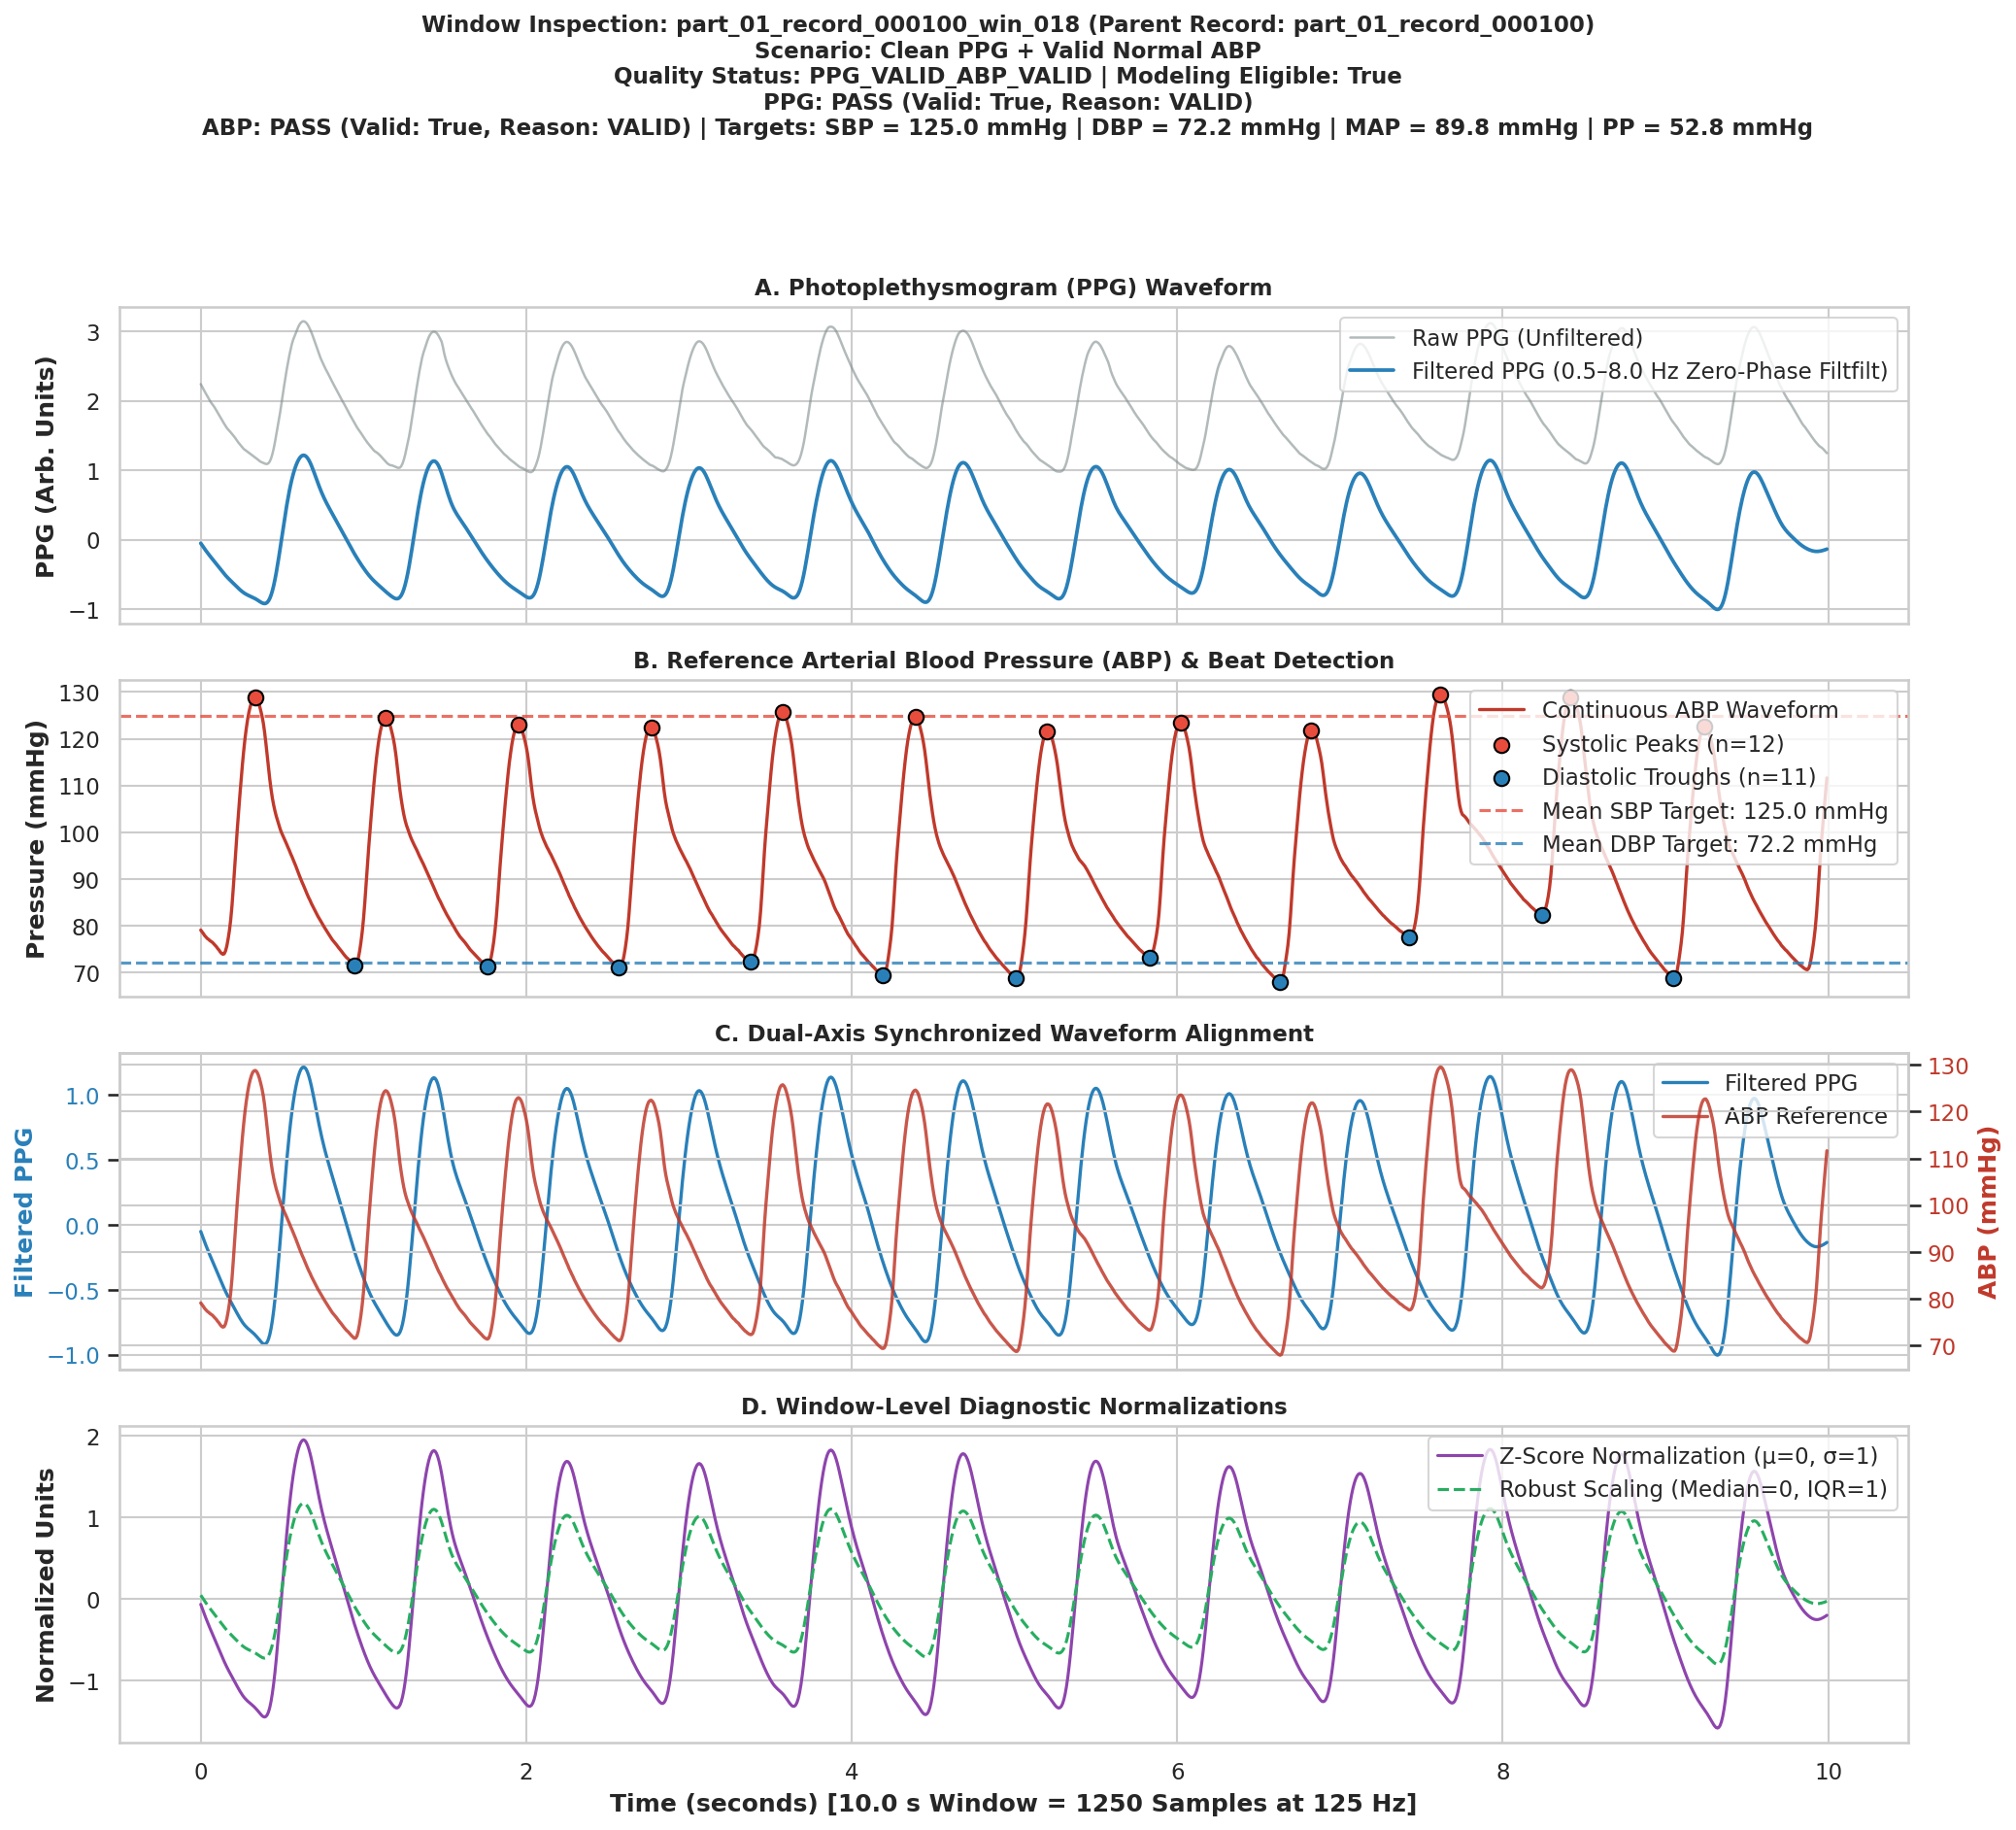

Figure: window_rep_02_baseline_drift.png


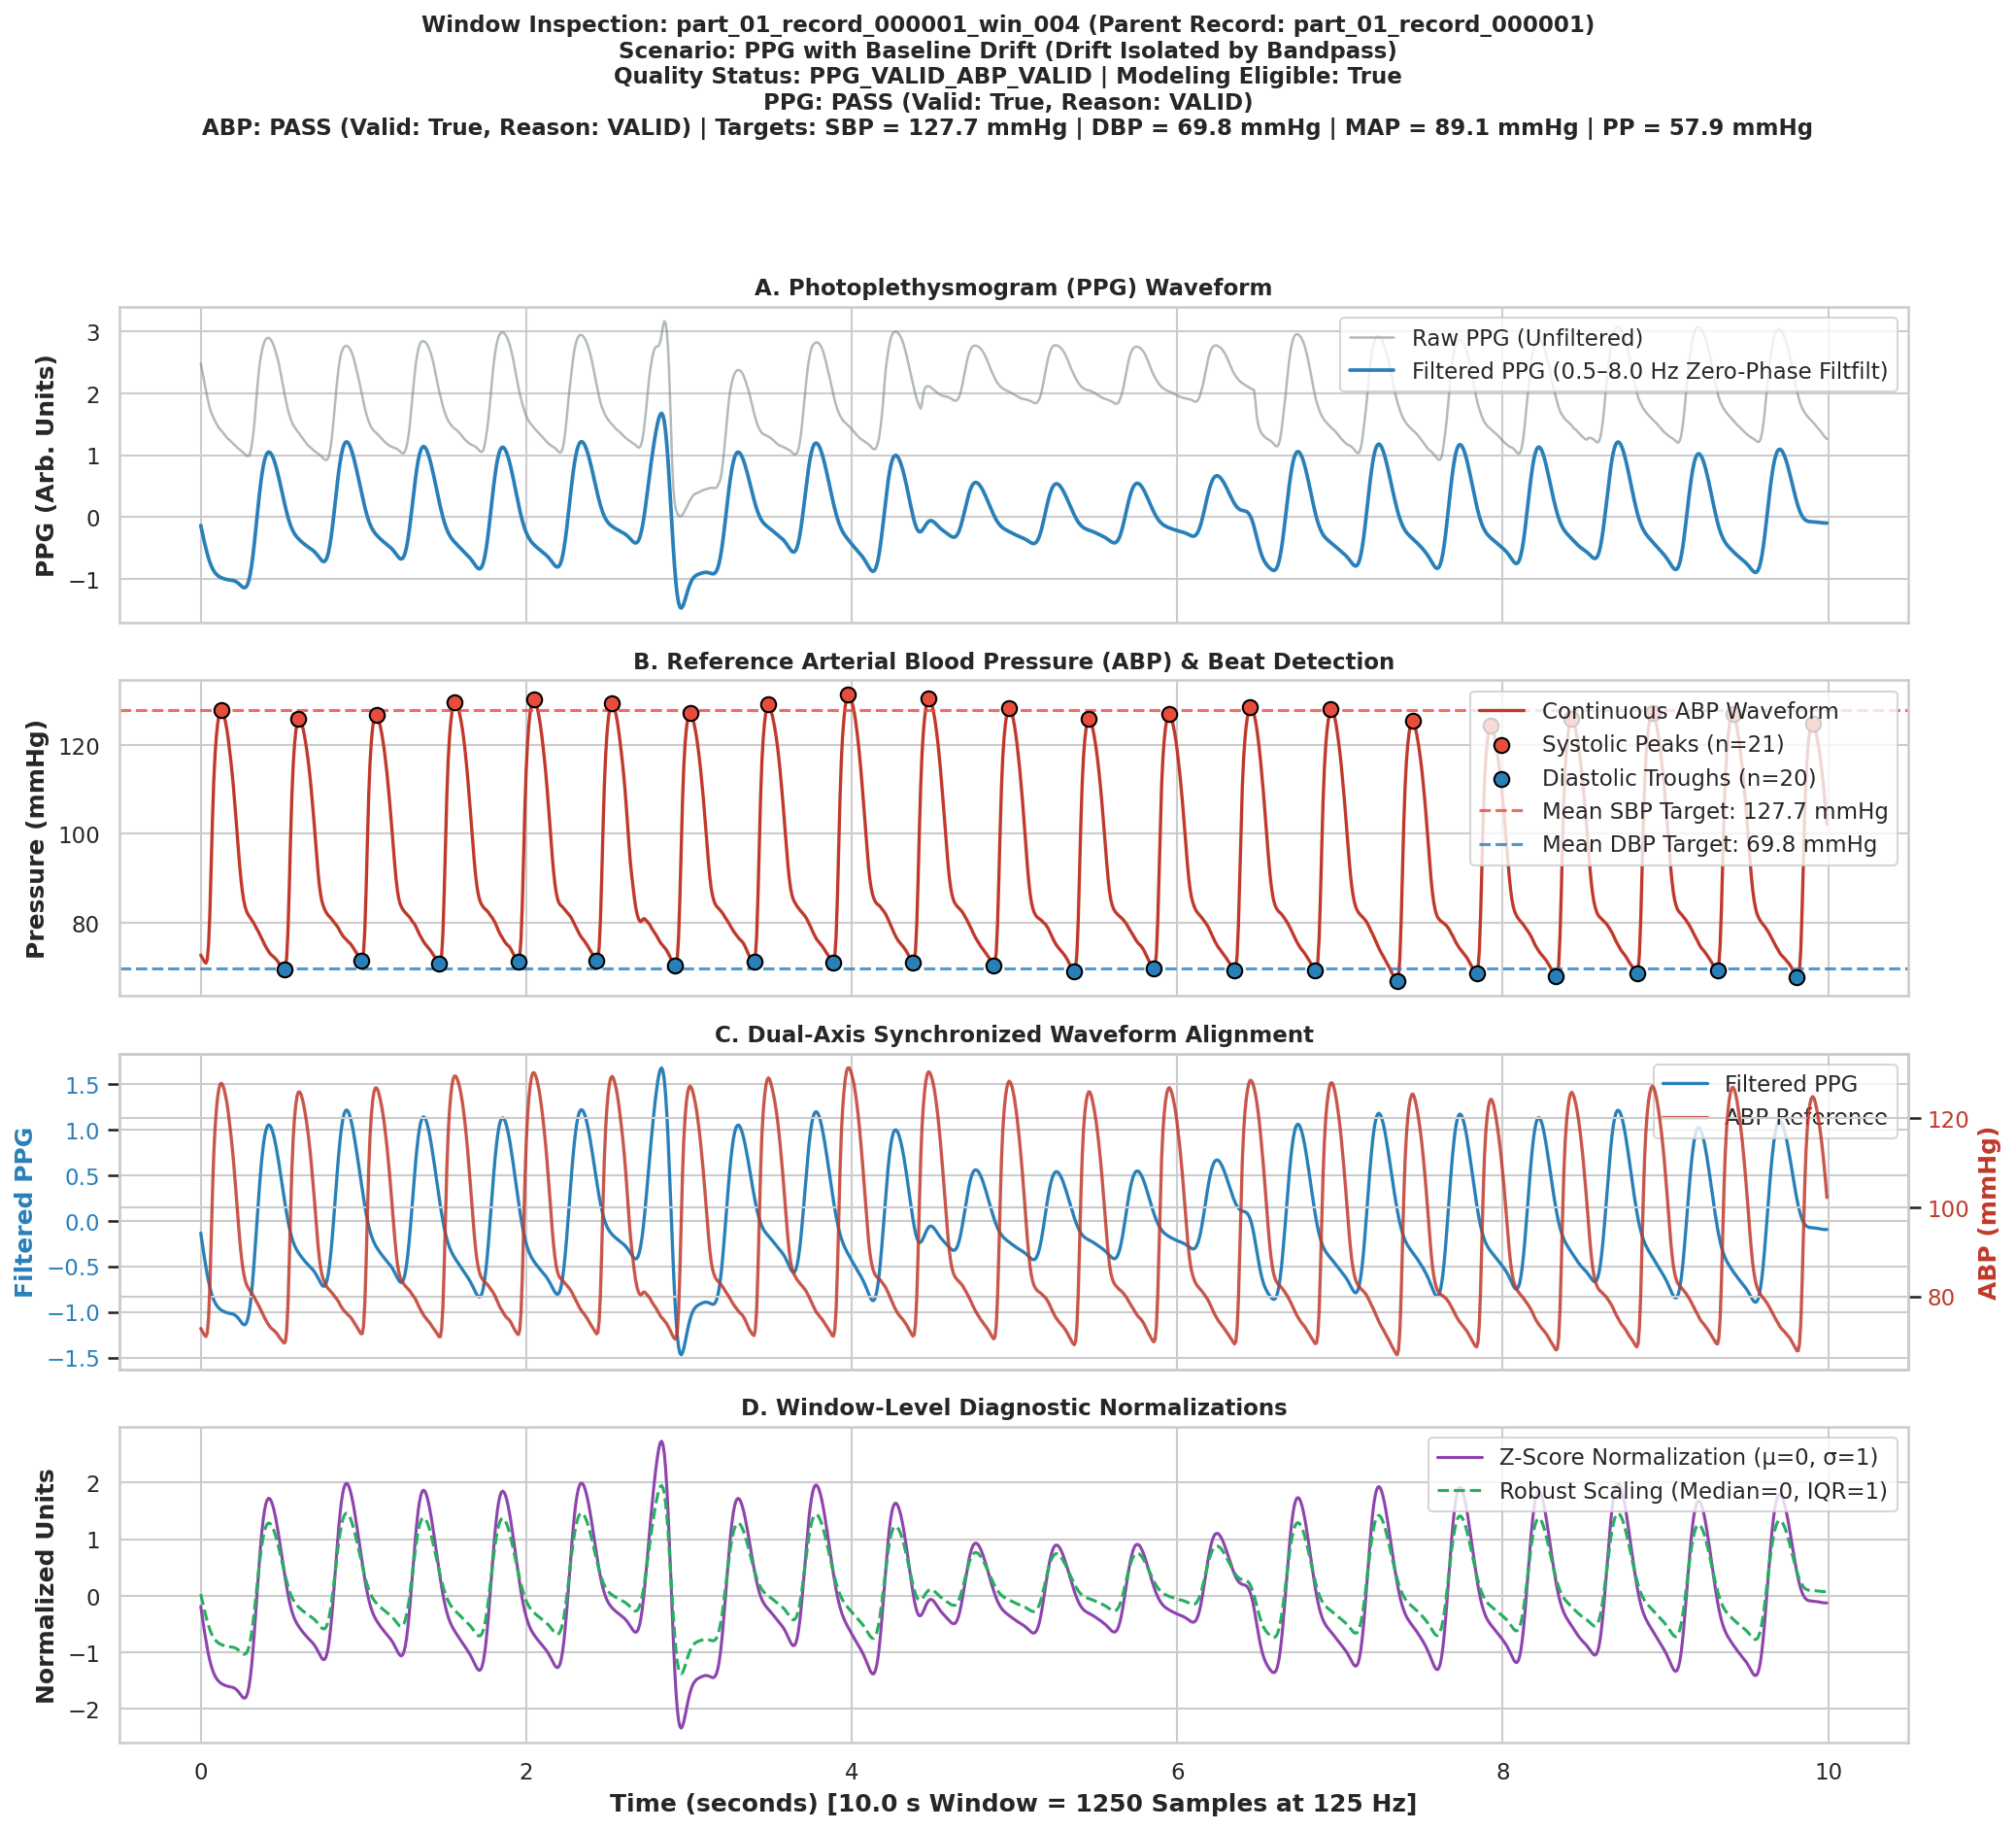

Figure: window_rep_03_motion_artifact.png


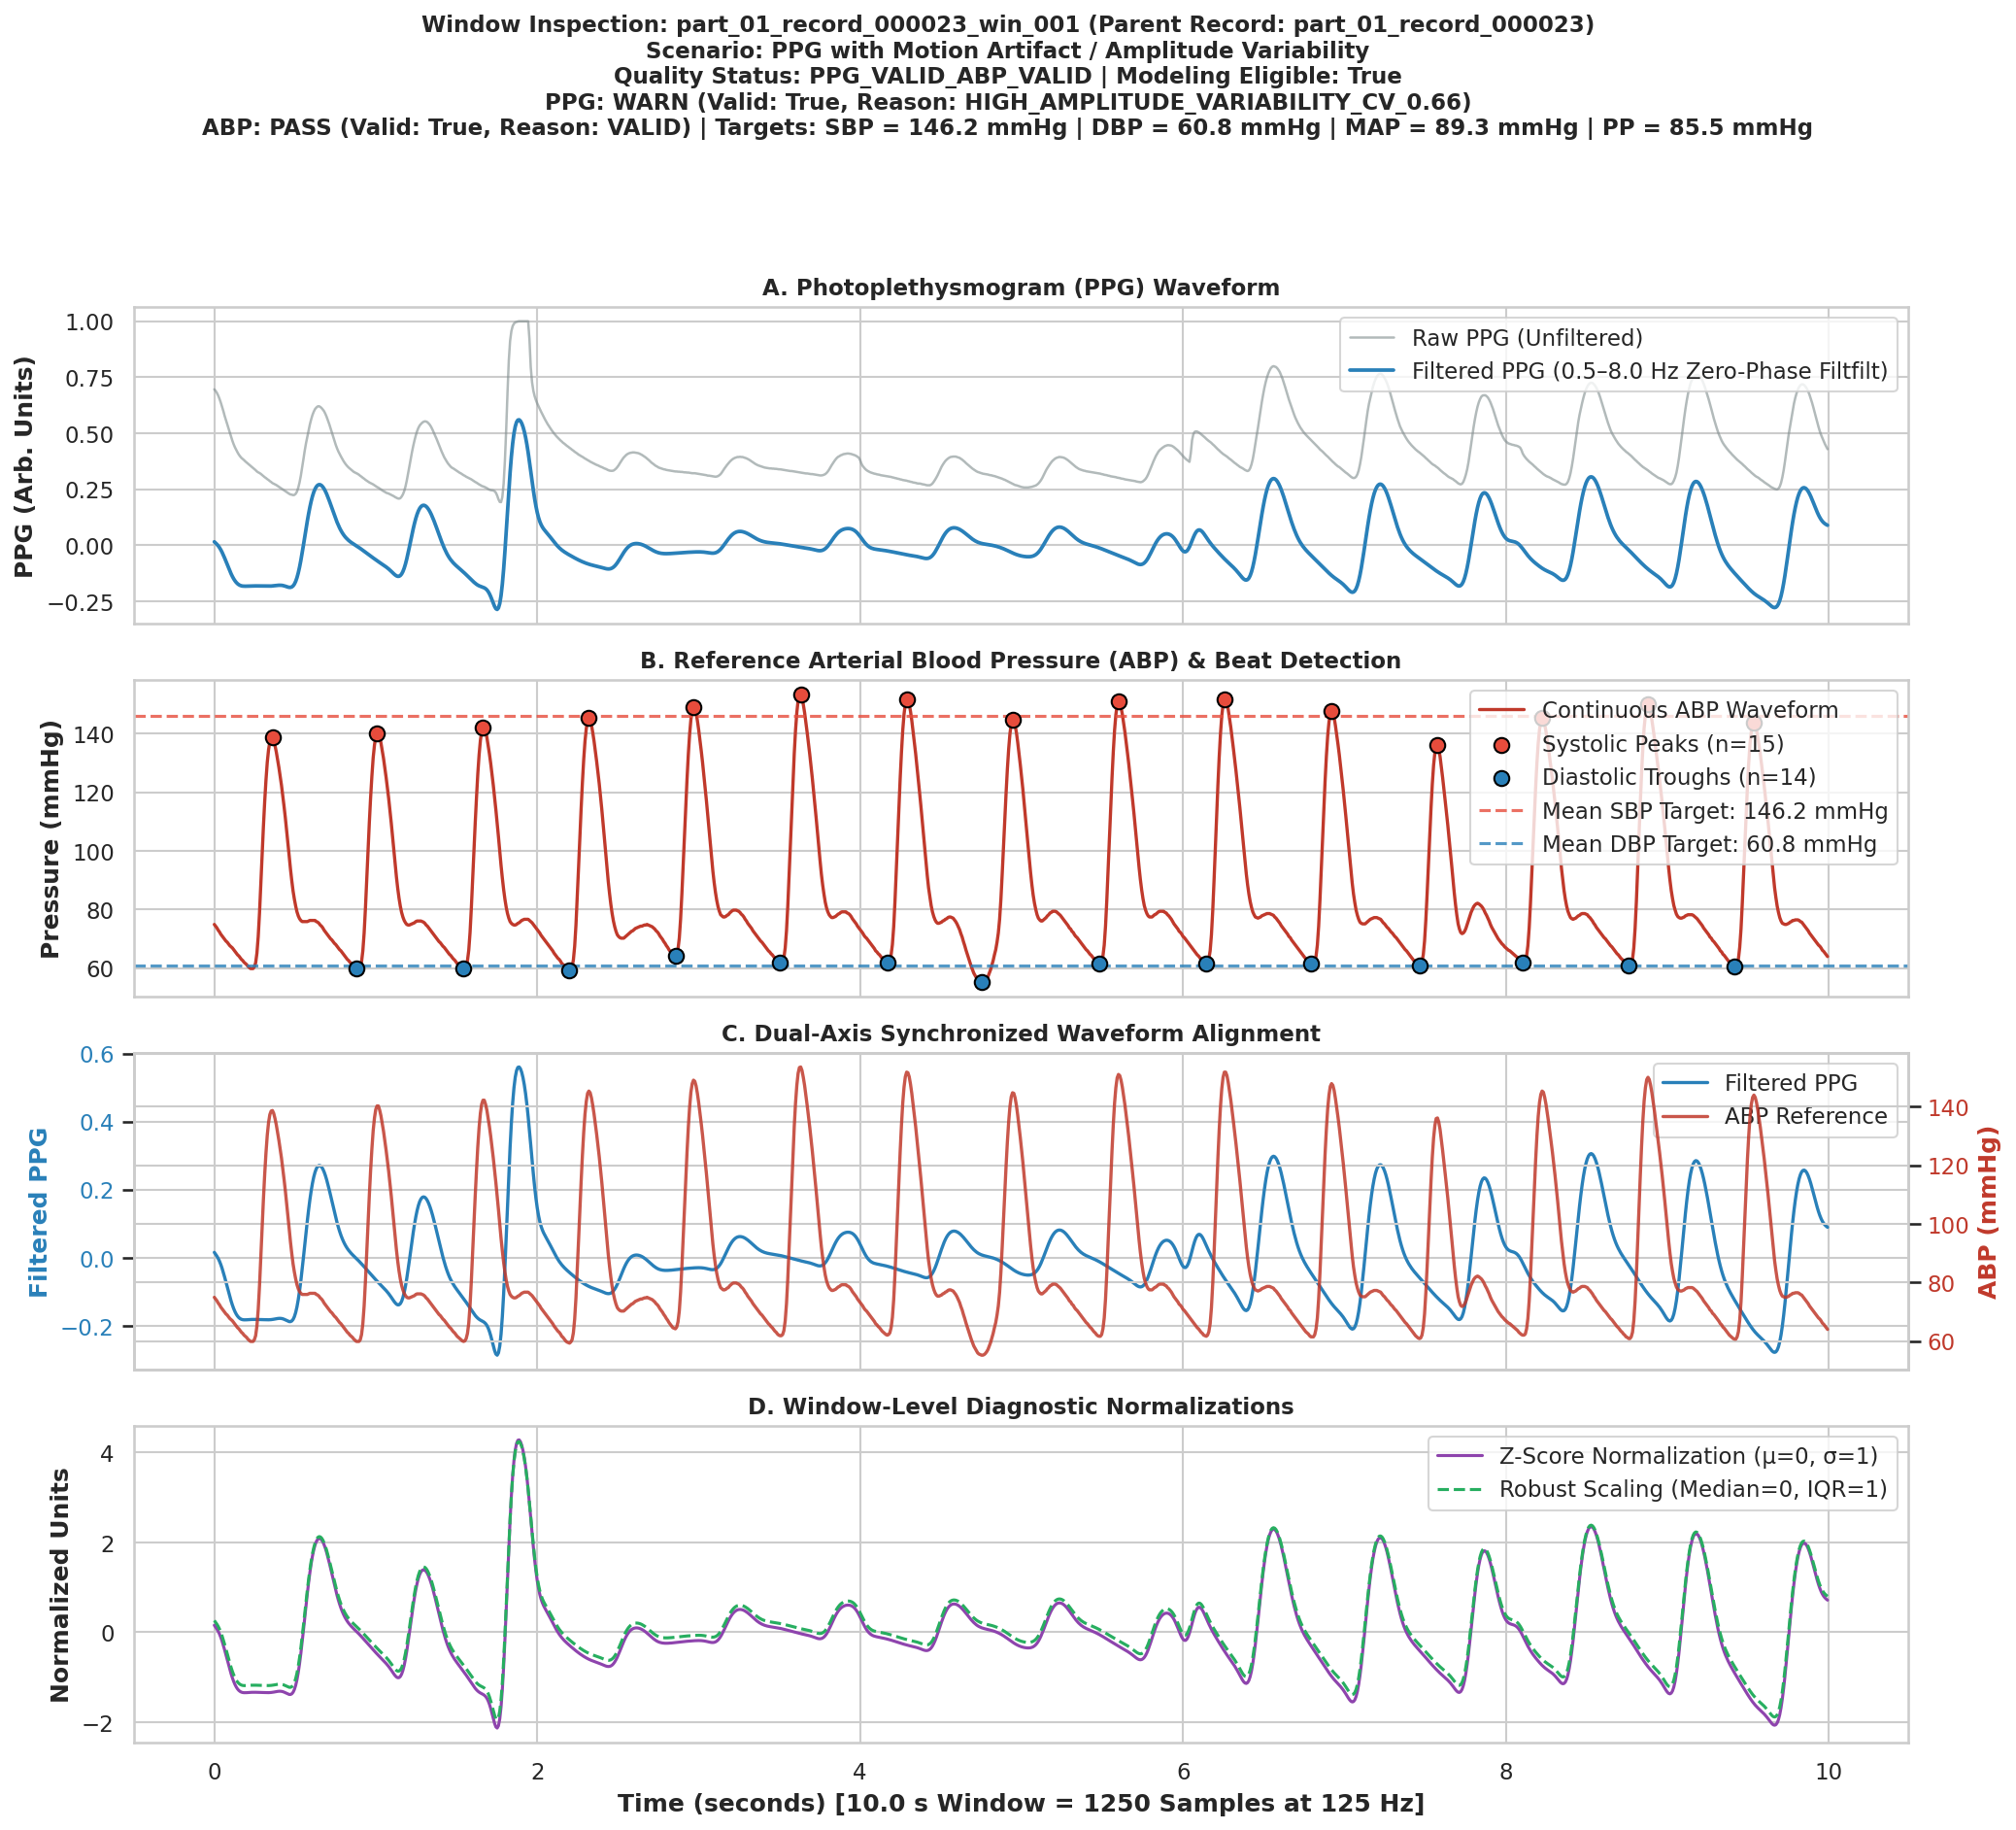

Figure: window_rep_04_clipping_saturation.png


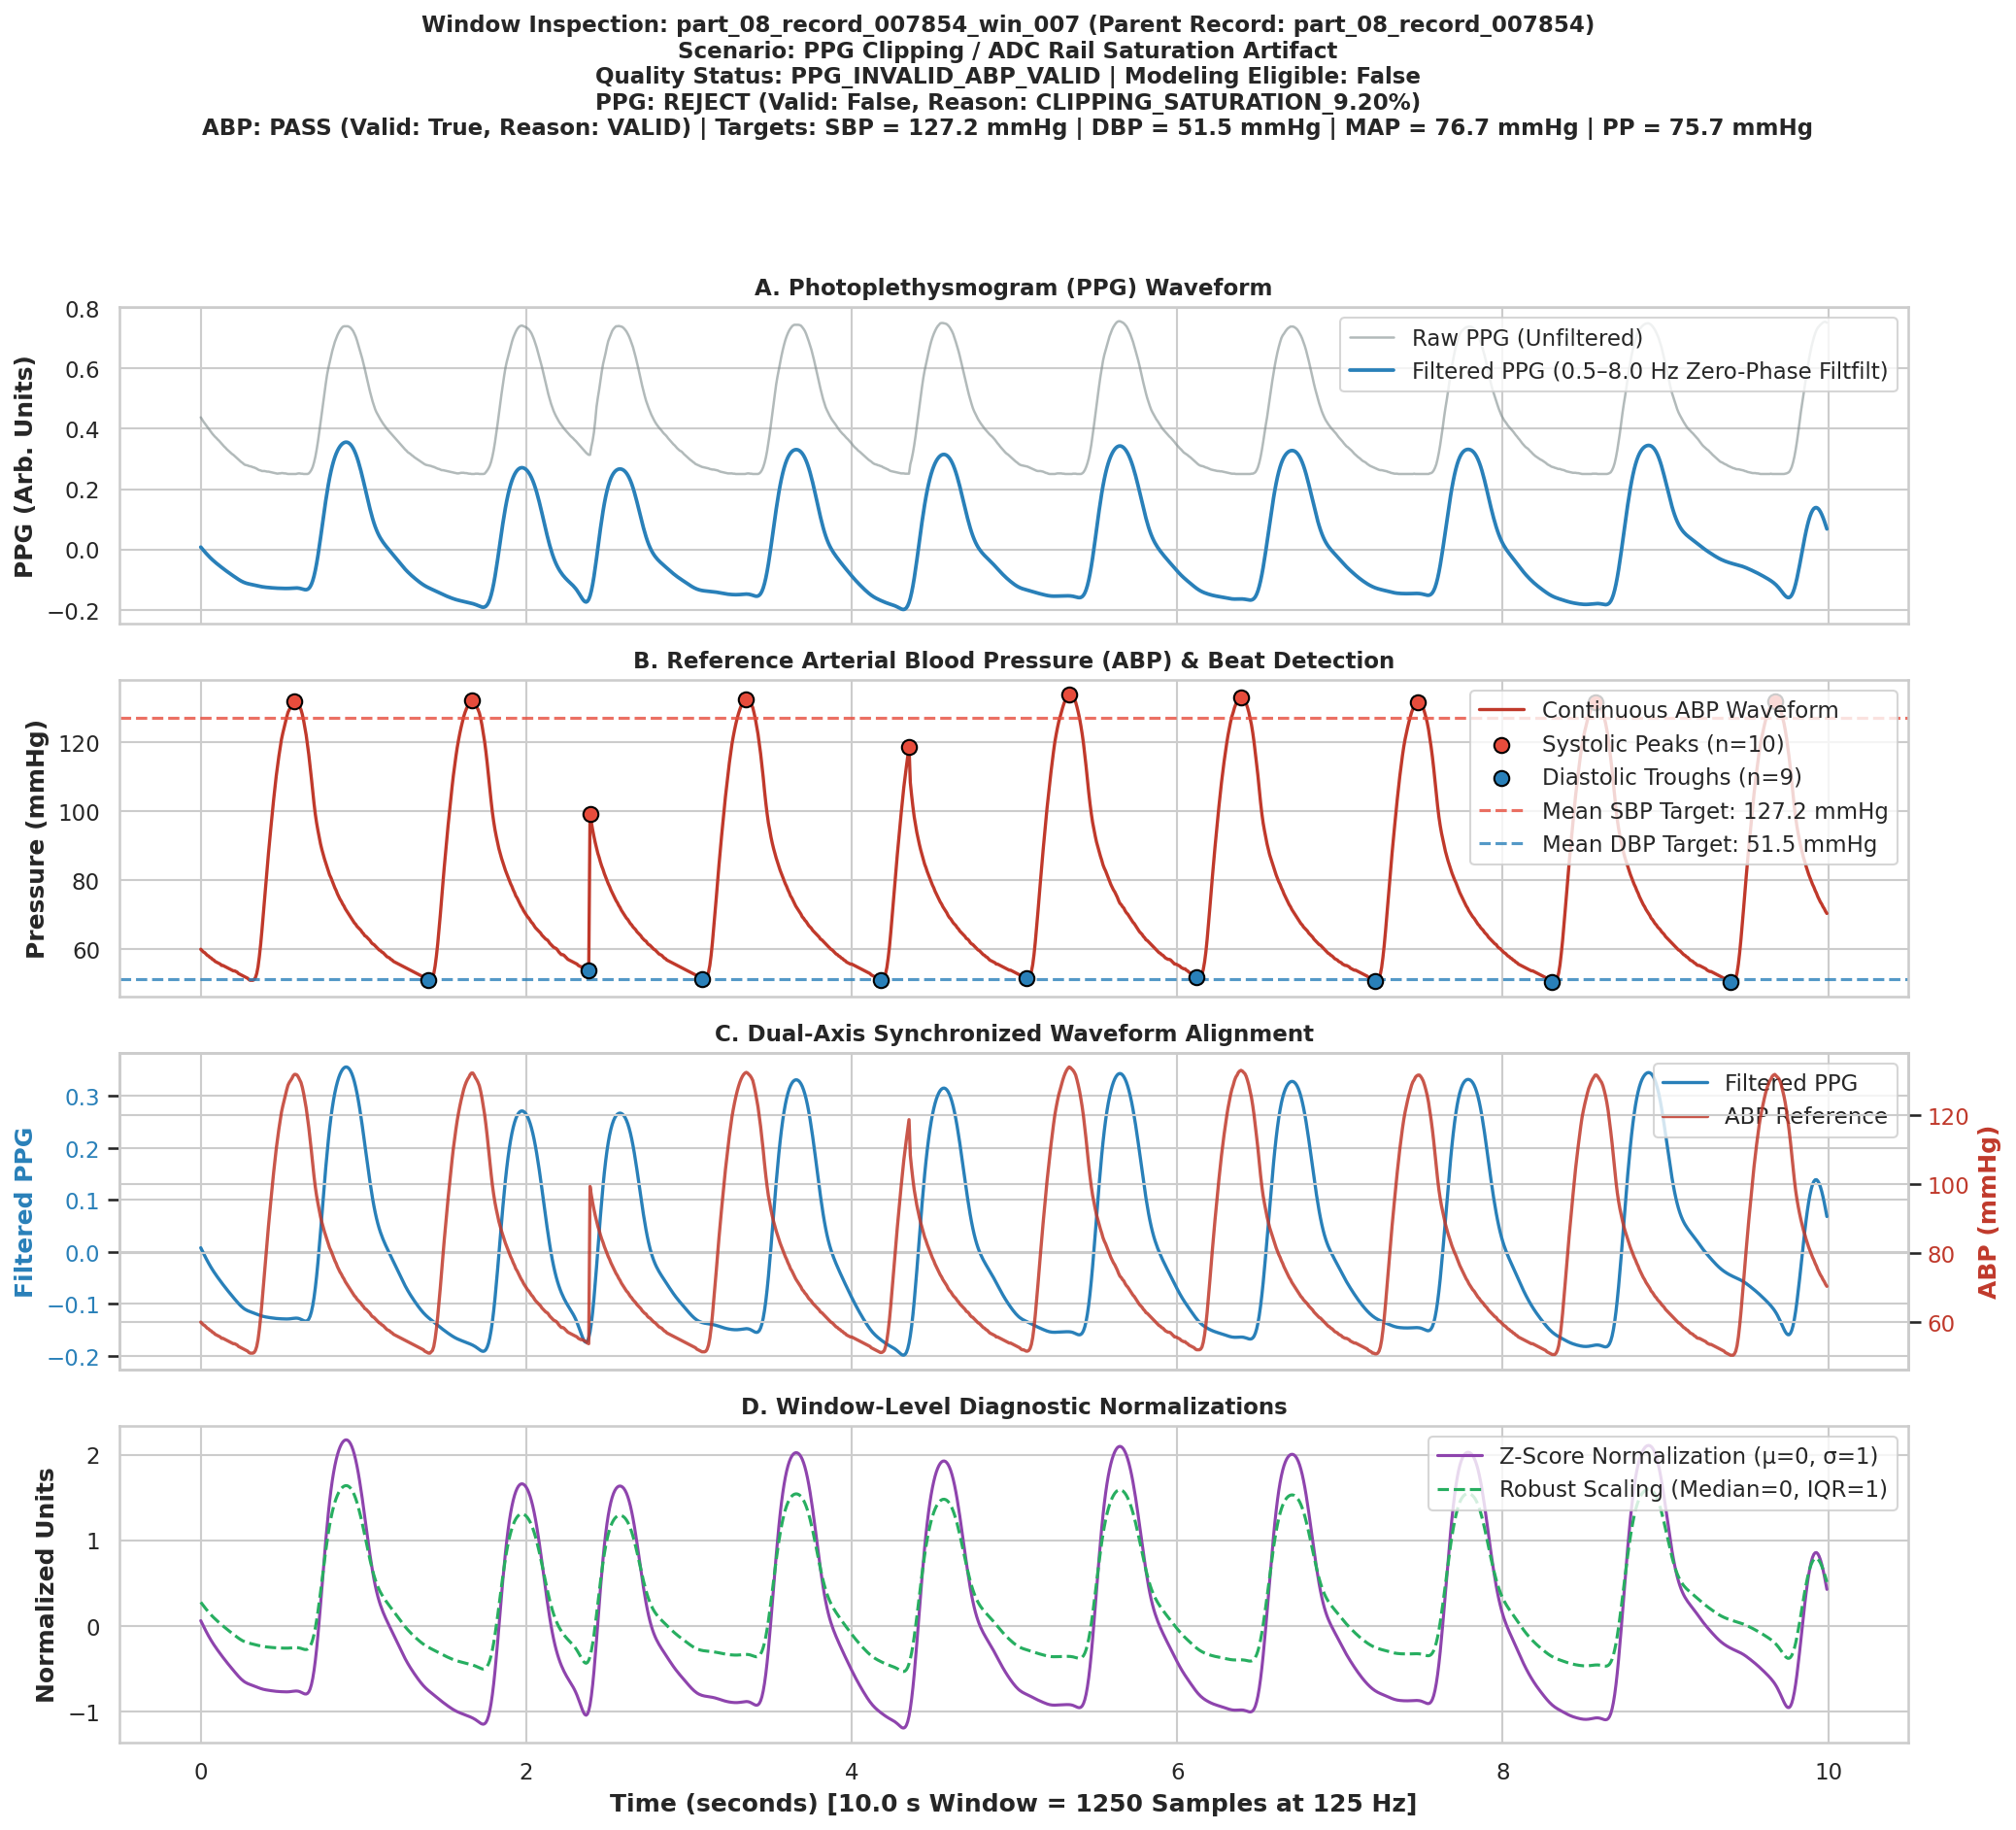

Figure: window_rep_05_poor_pulse_morphology.png


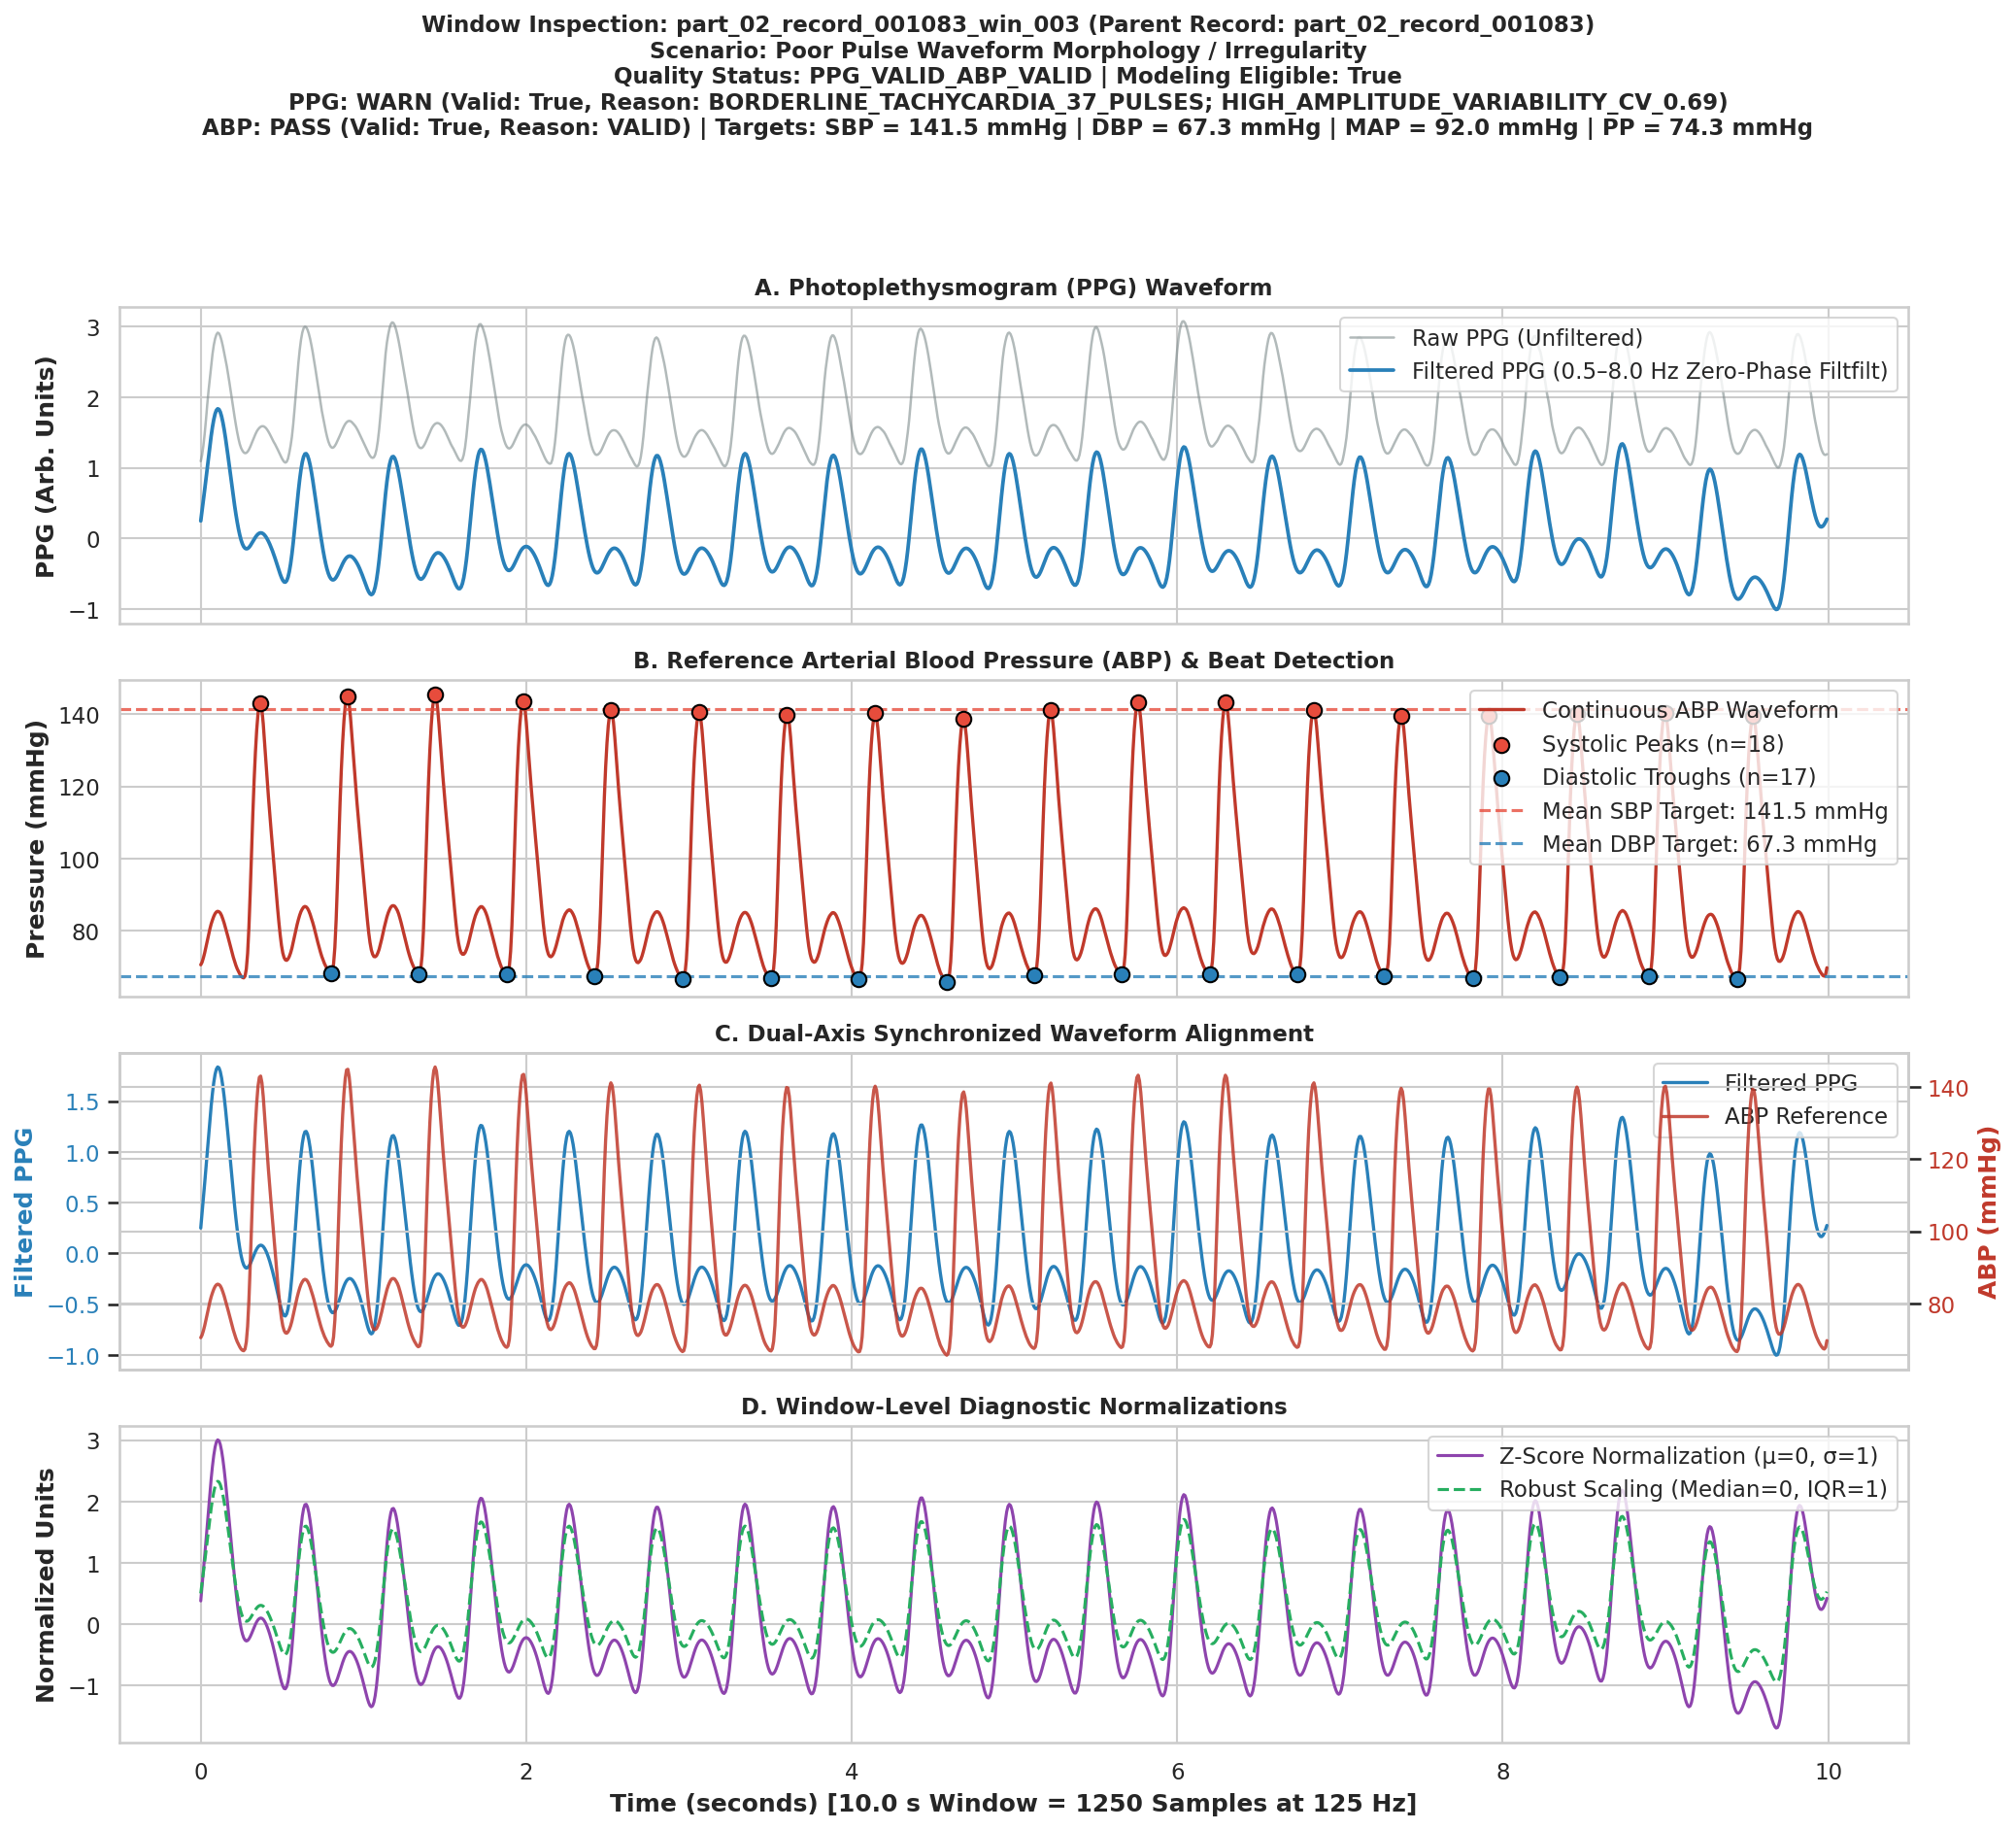

Figure: window_rep_06_invalid_abp_usable_ppg.png


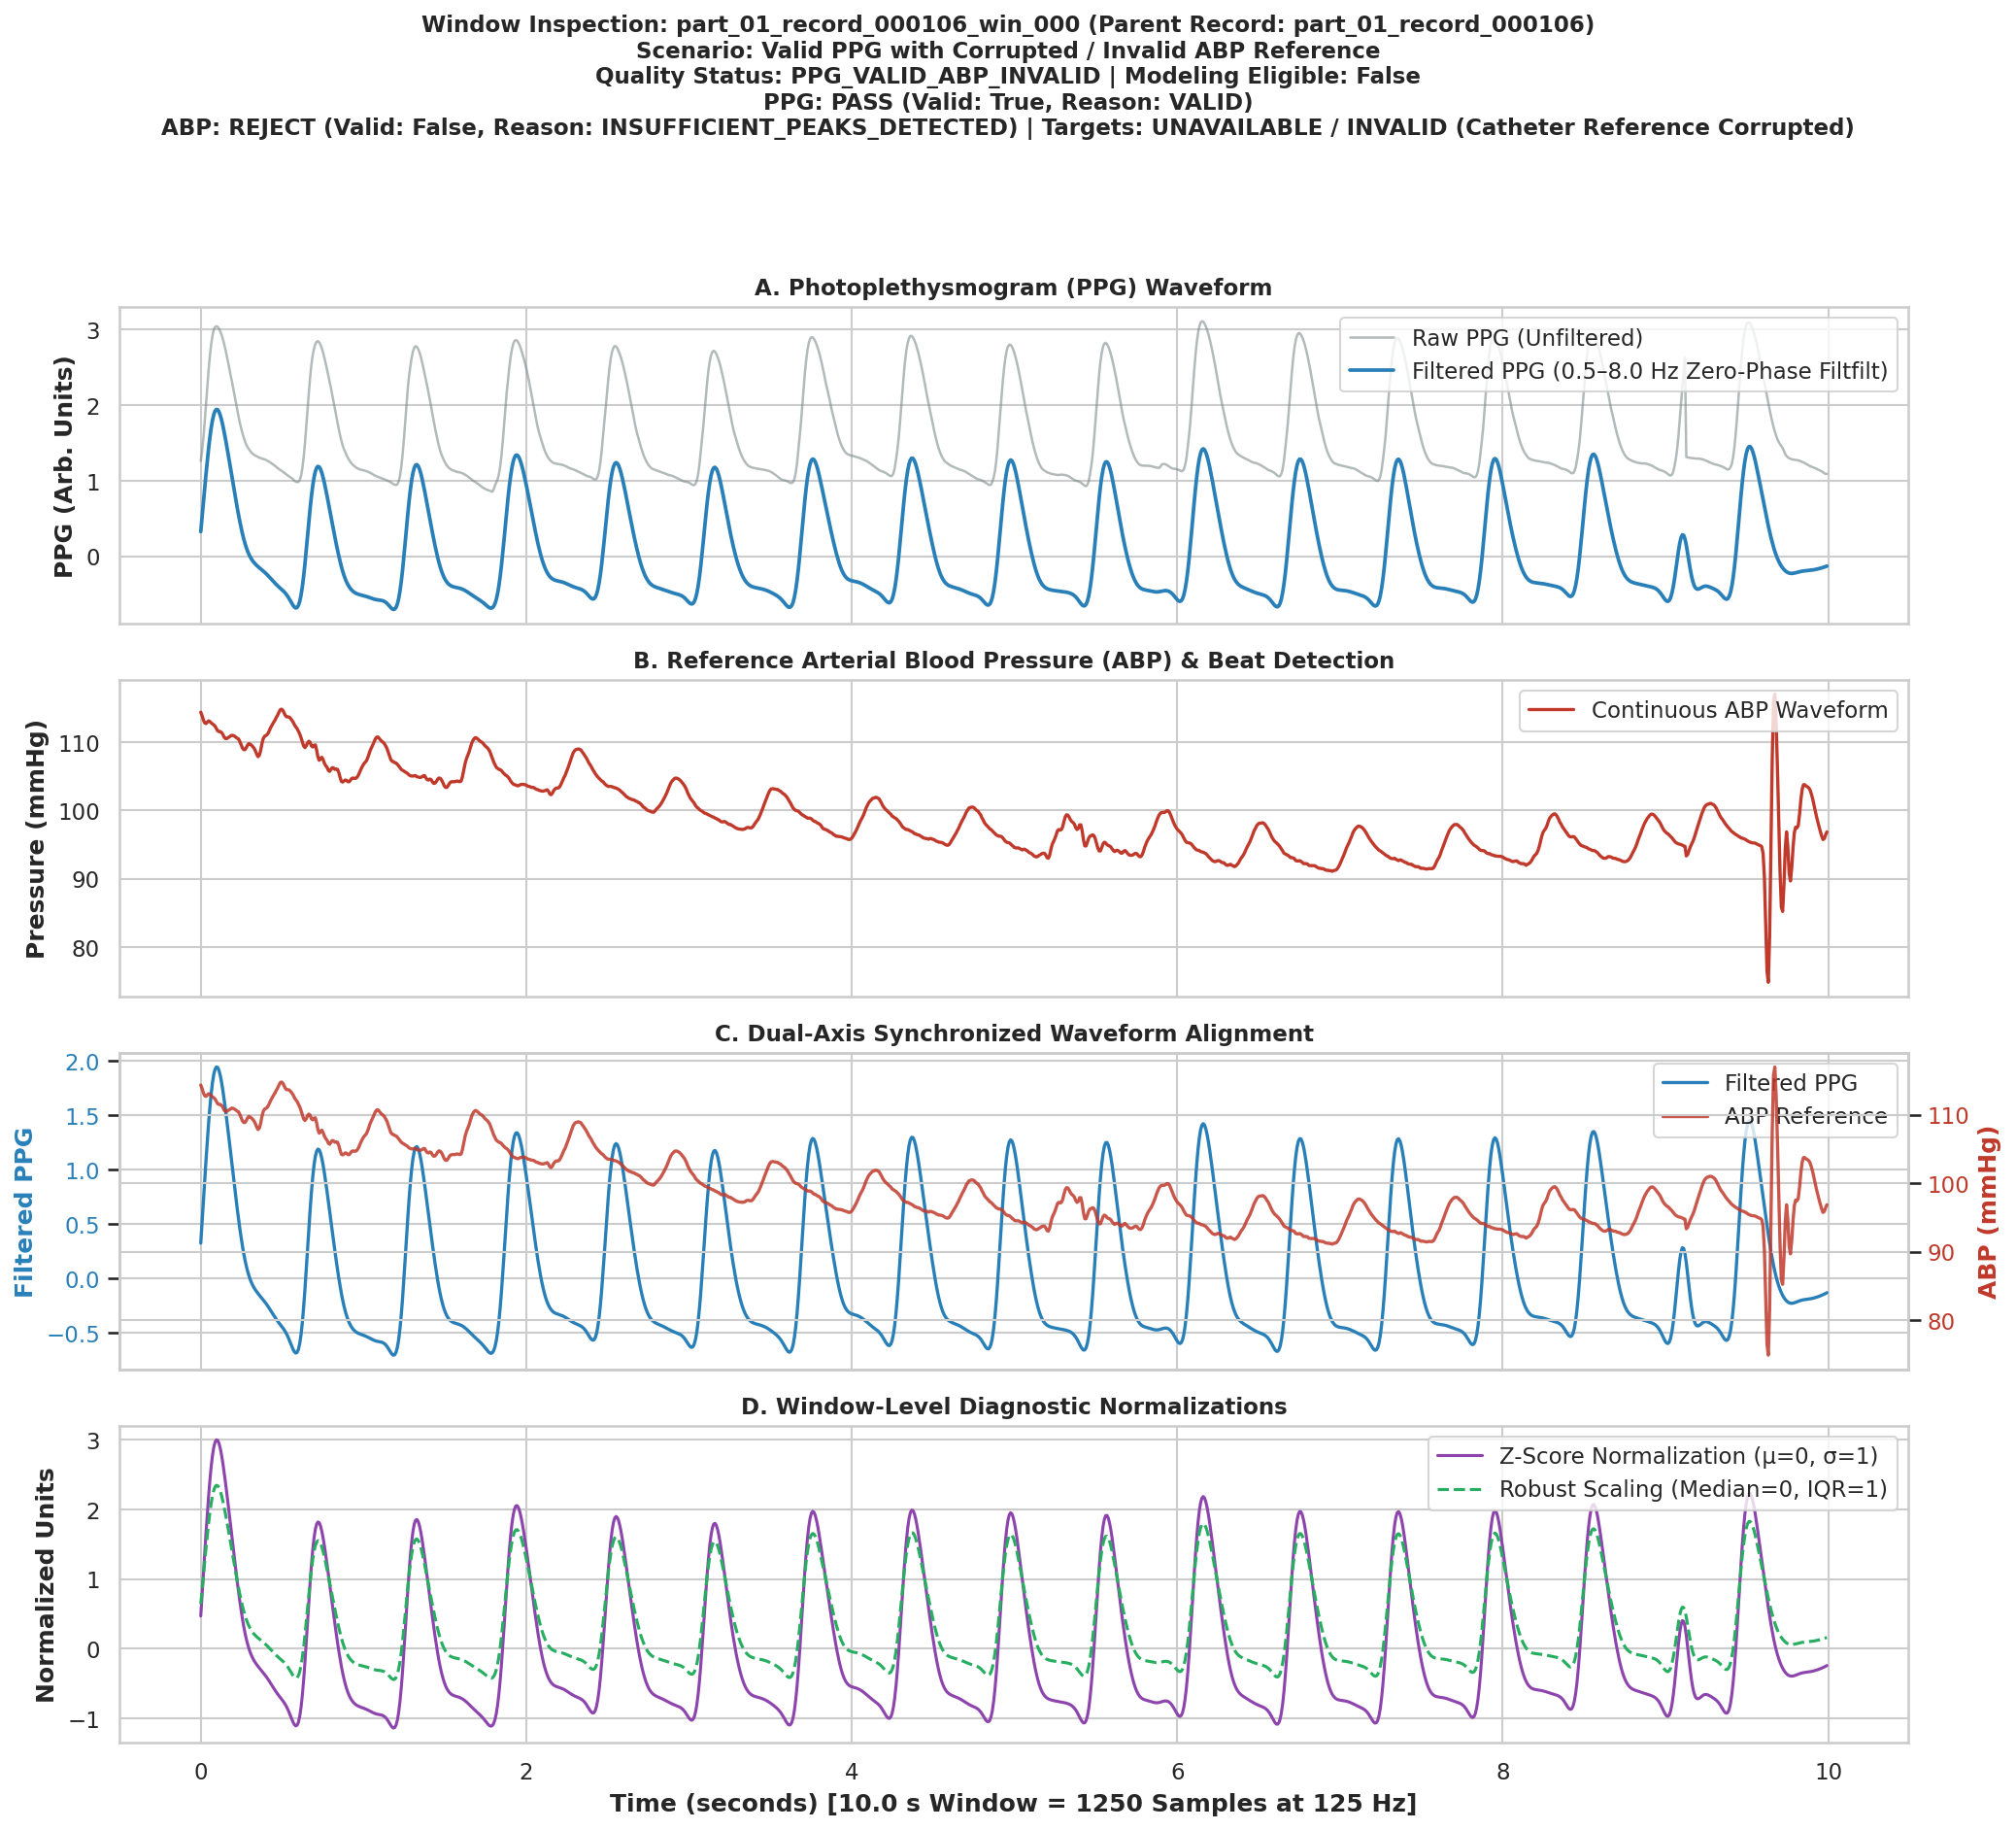

Figure: window_rep_07_hypertensive_valid.png


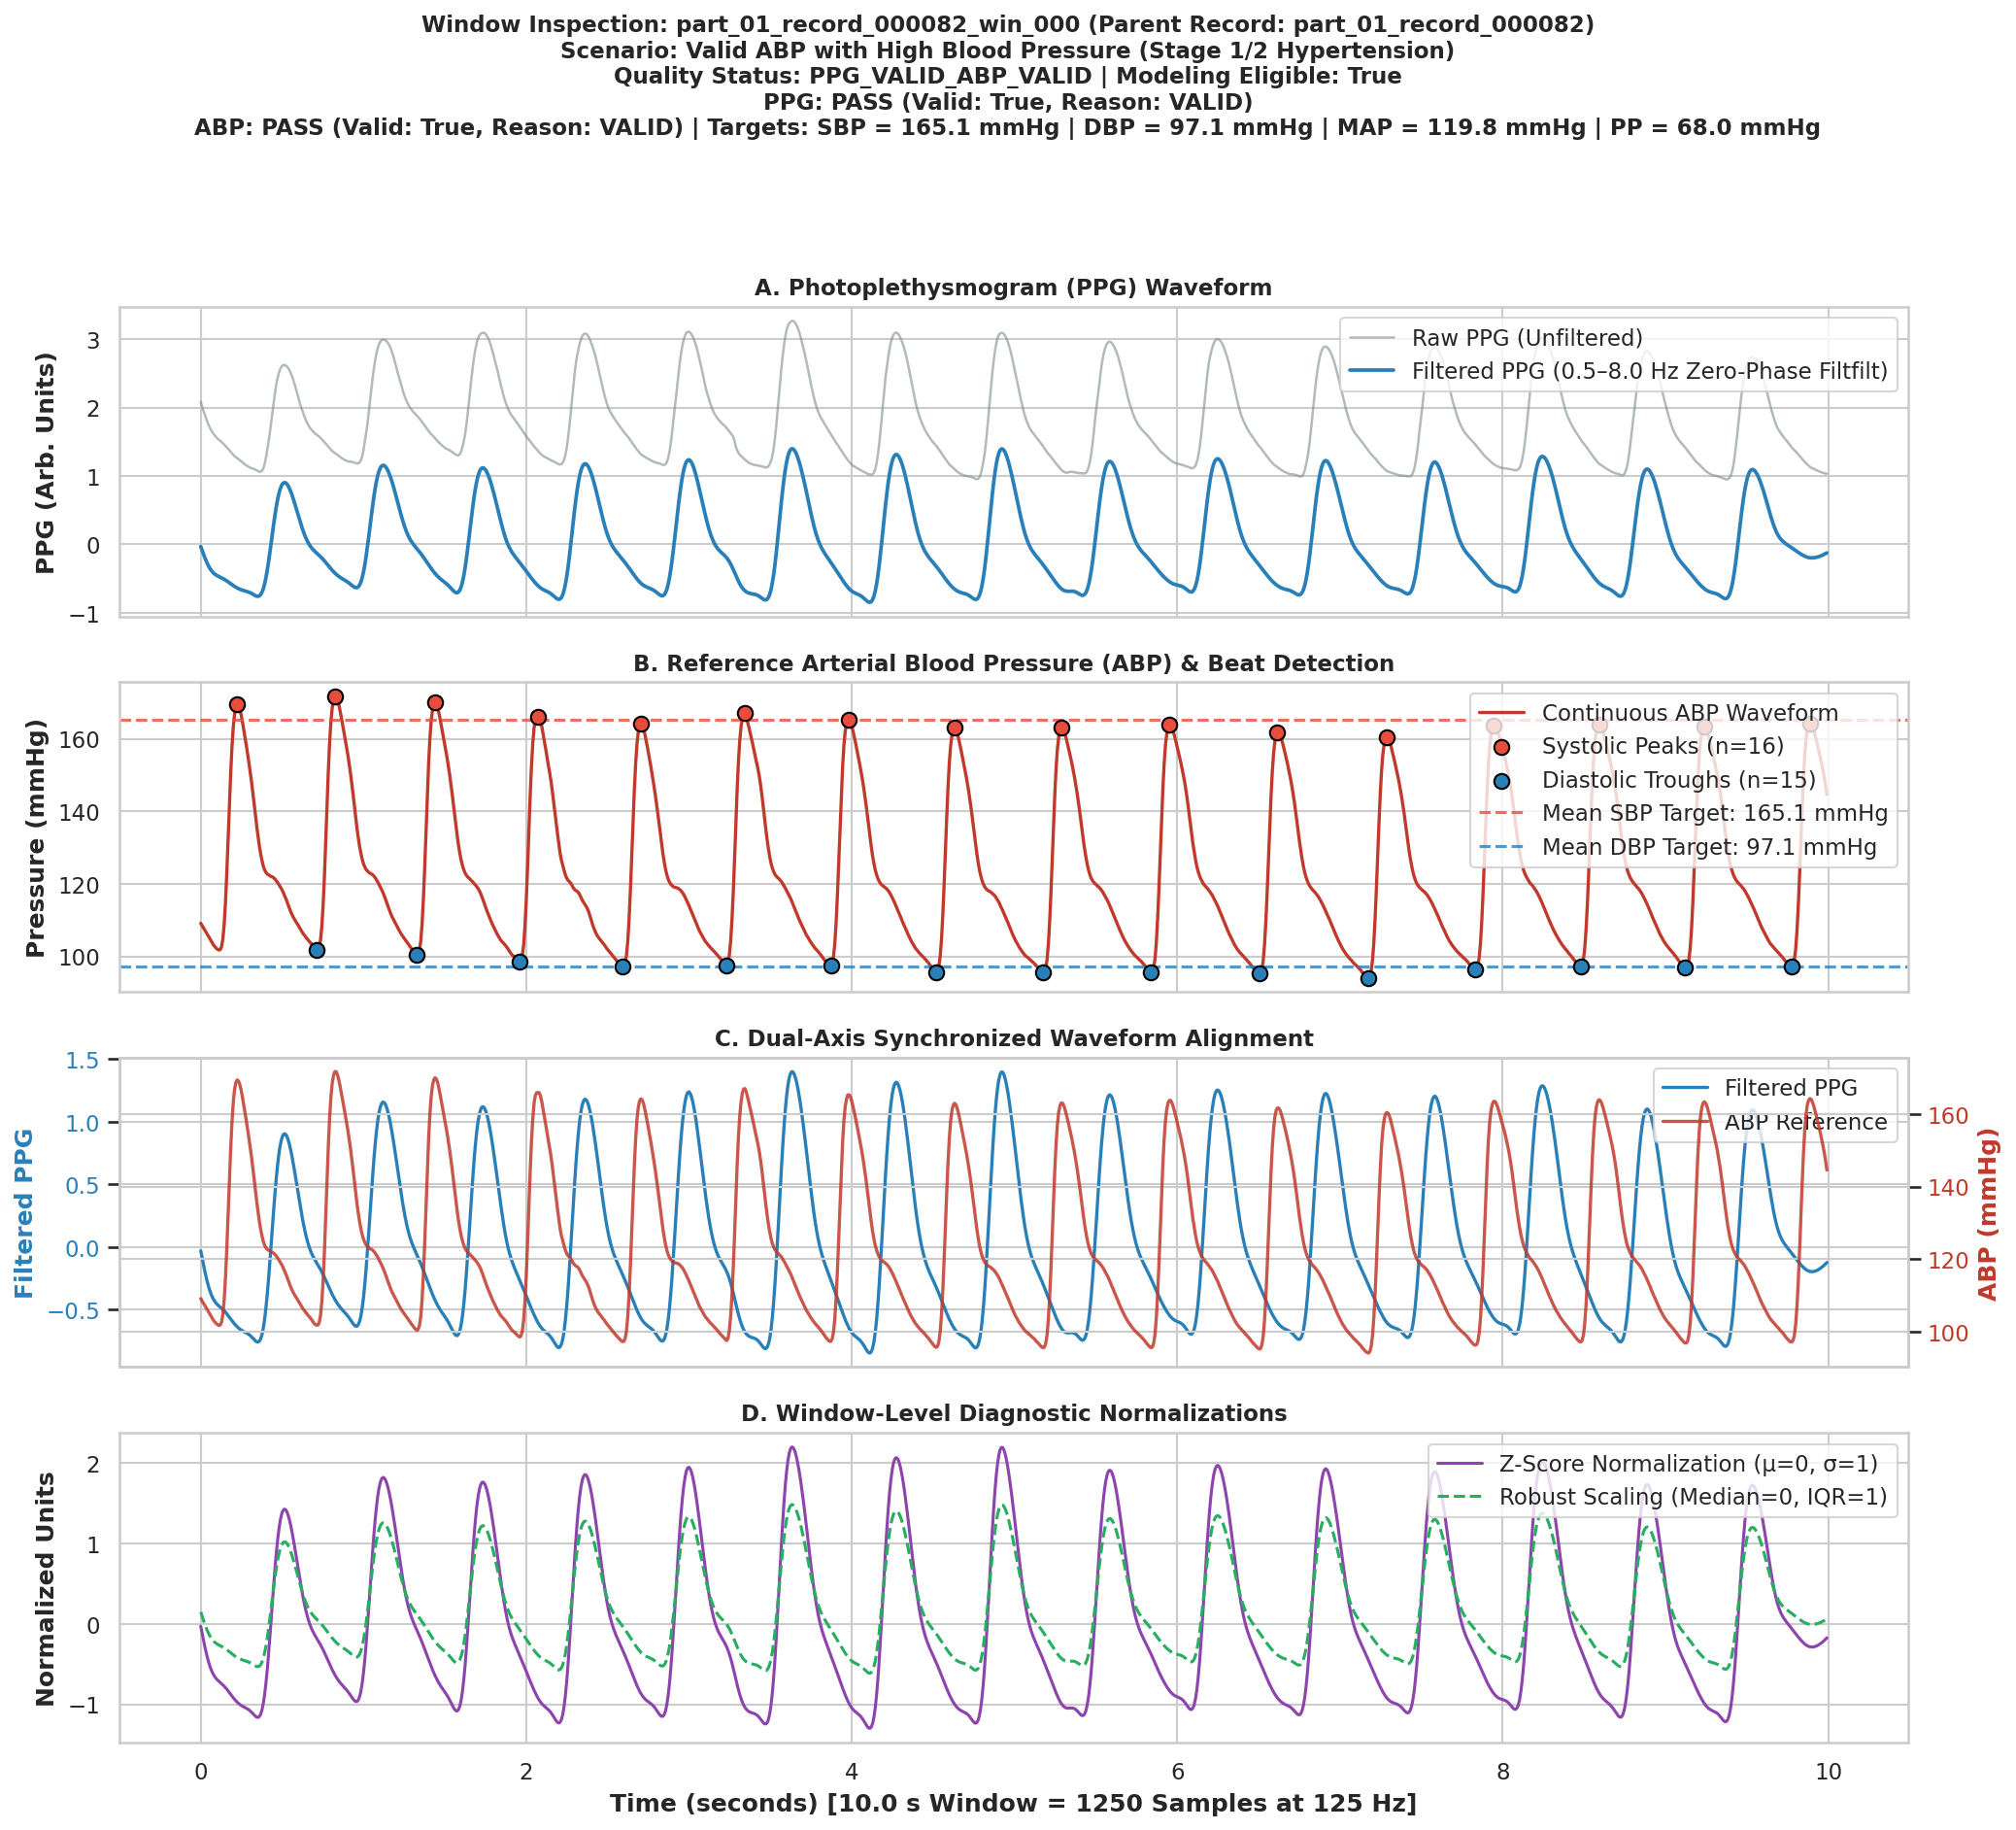

Figure: window_rep_08_borderline_warn.png


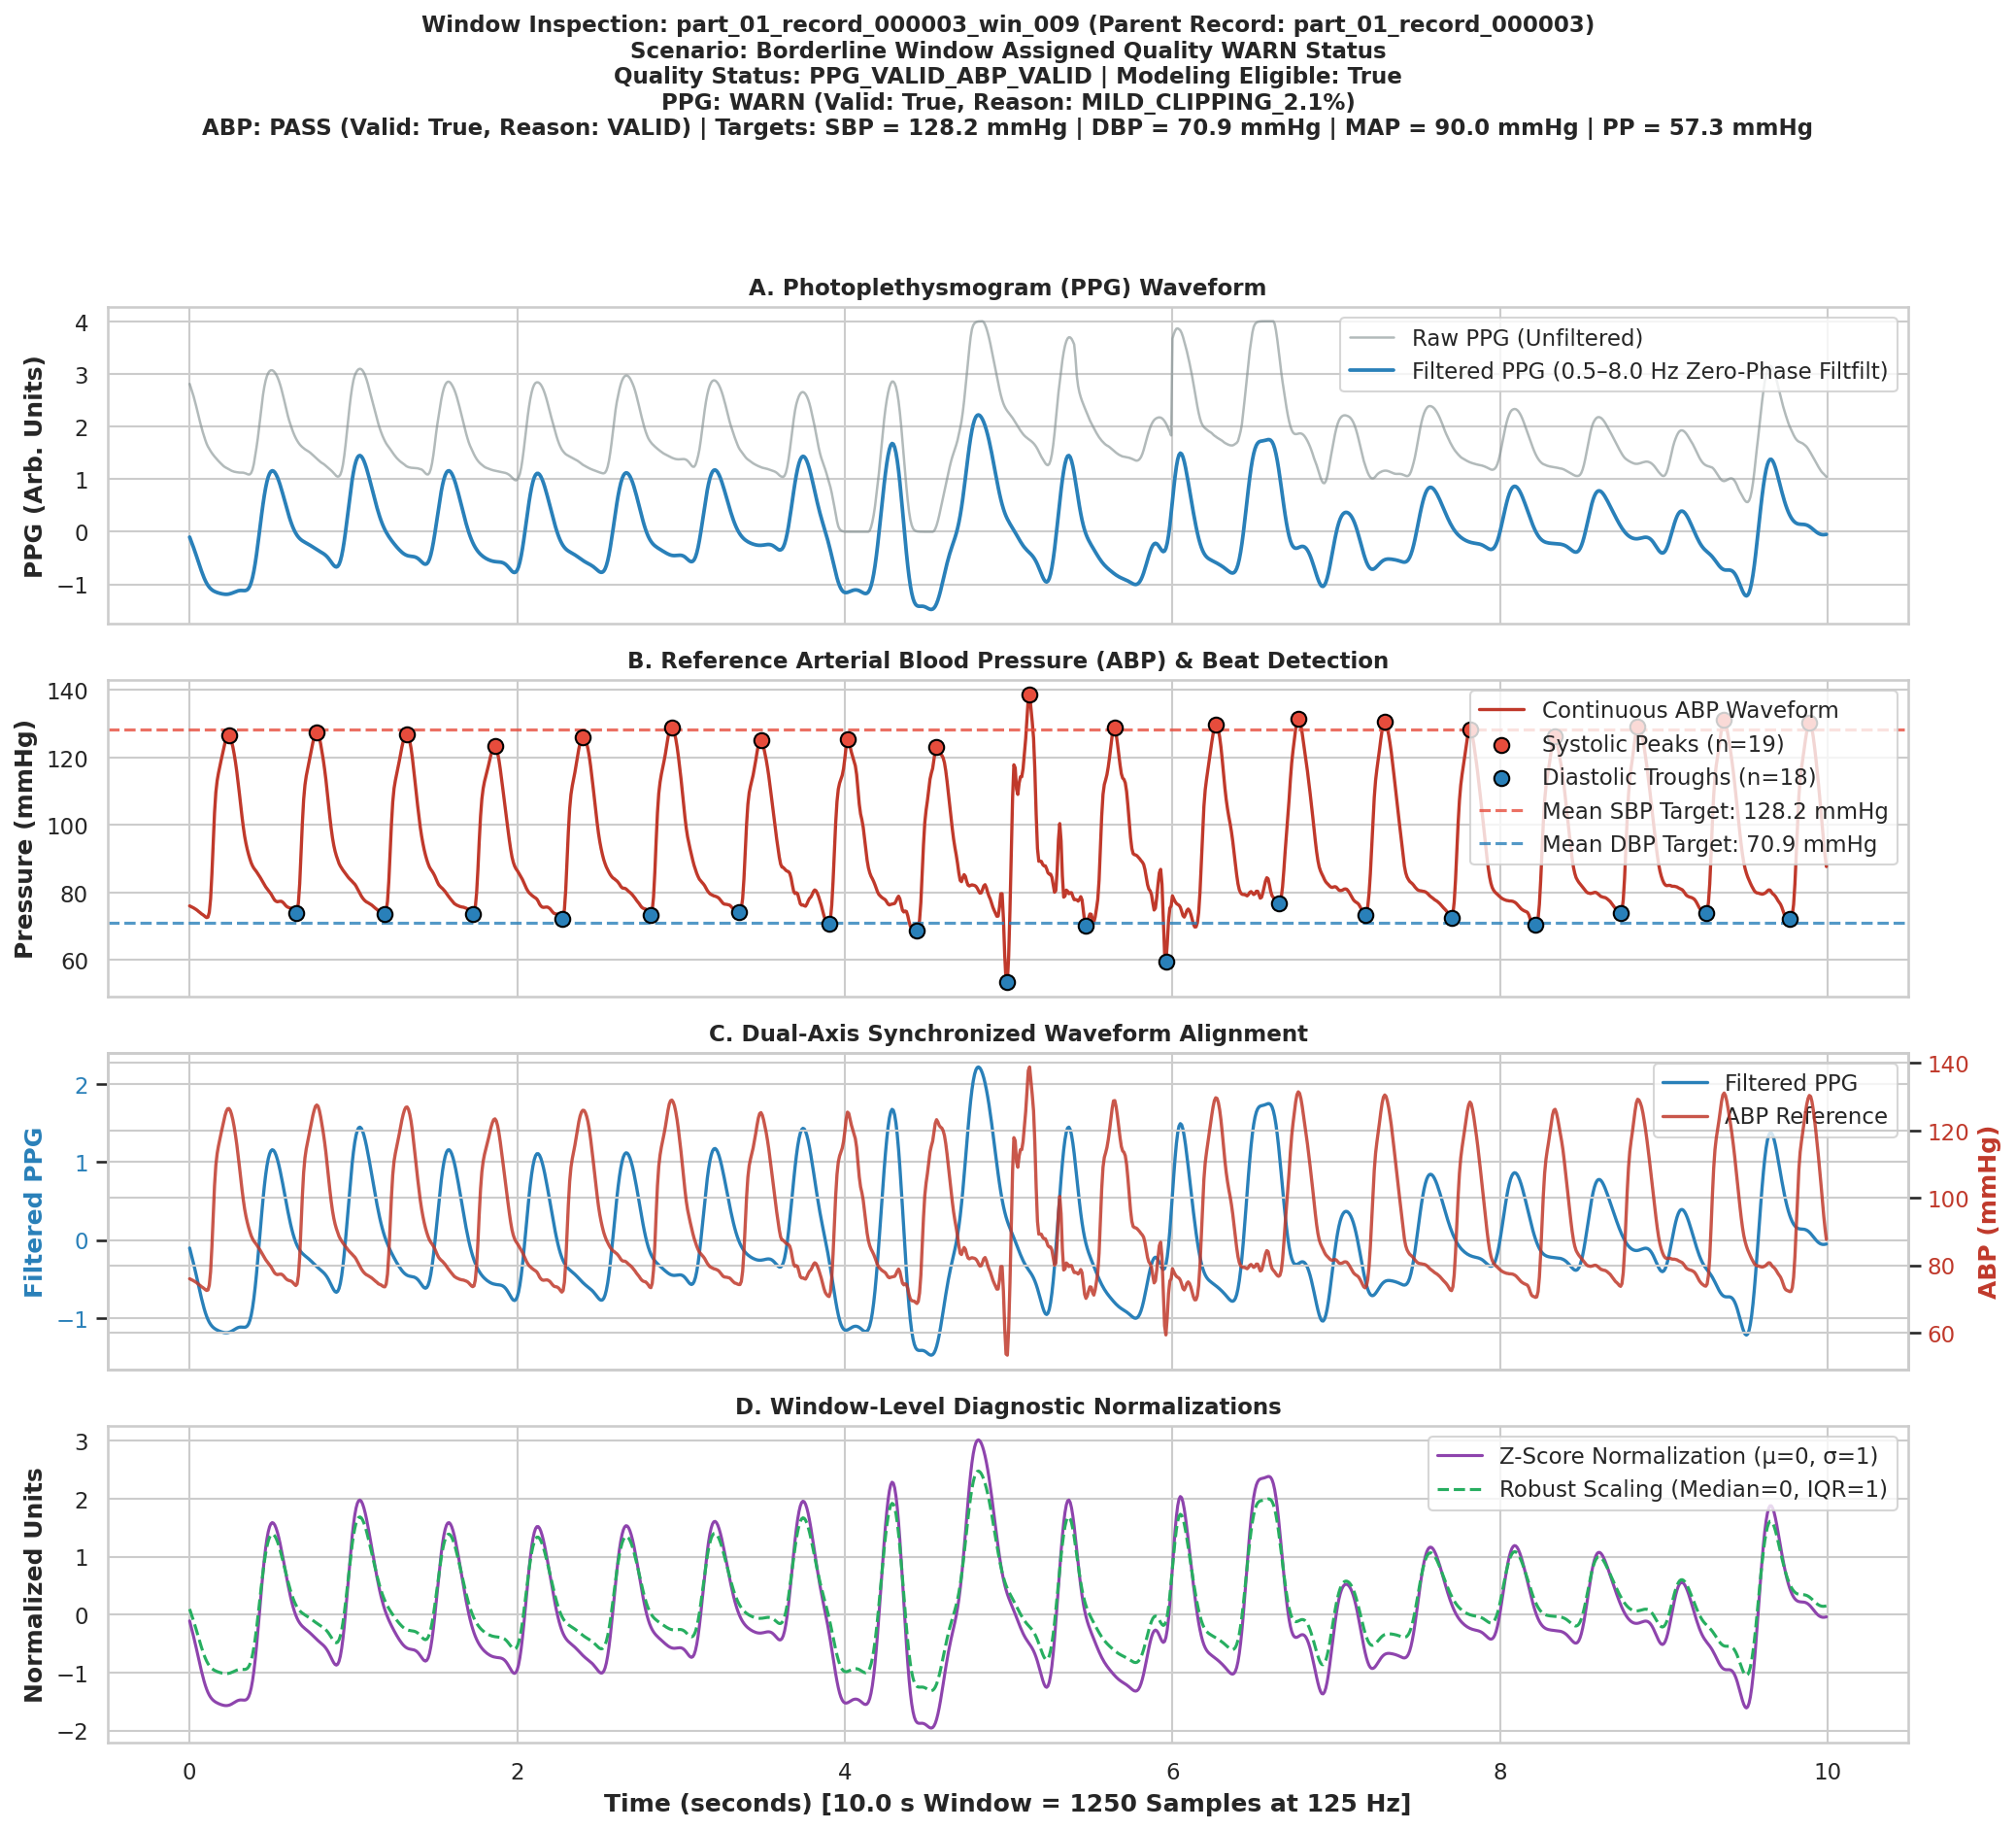

In [11]:
import glob
from IPython.display import Image, display

# Display representative window figures generated in Phase 2
rep_figures = sorted(glob.glob(str(FIGURES_DIR / "window_rep_*.png")))
print(f"Discovered {len(rep_figures)} representative scenario figures.")

for fig_path in rep_figures:
    fname = Path(fig_path).name
    print(f"Figure: {fname}")
    display(Image(filename=fig_path, width=900))

## 14. Diagnostic PPG Normalization Exploration

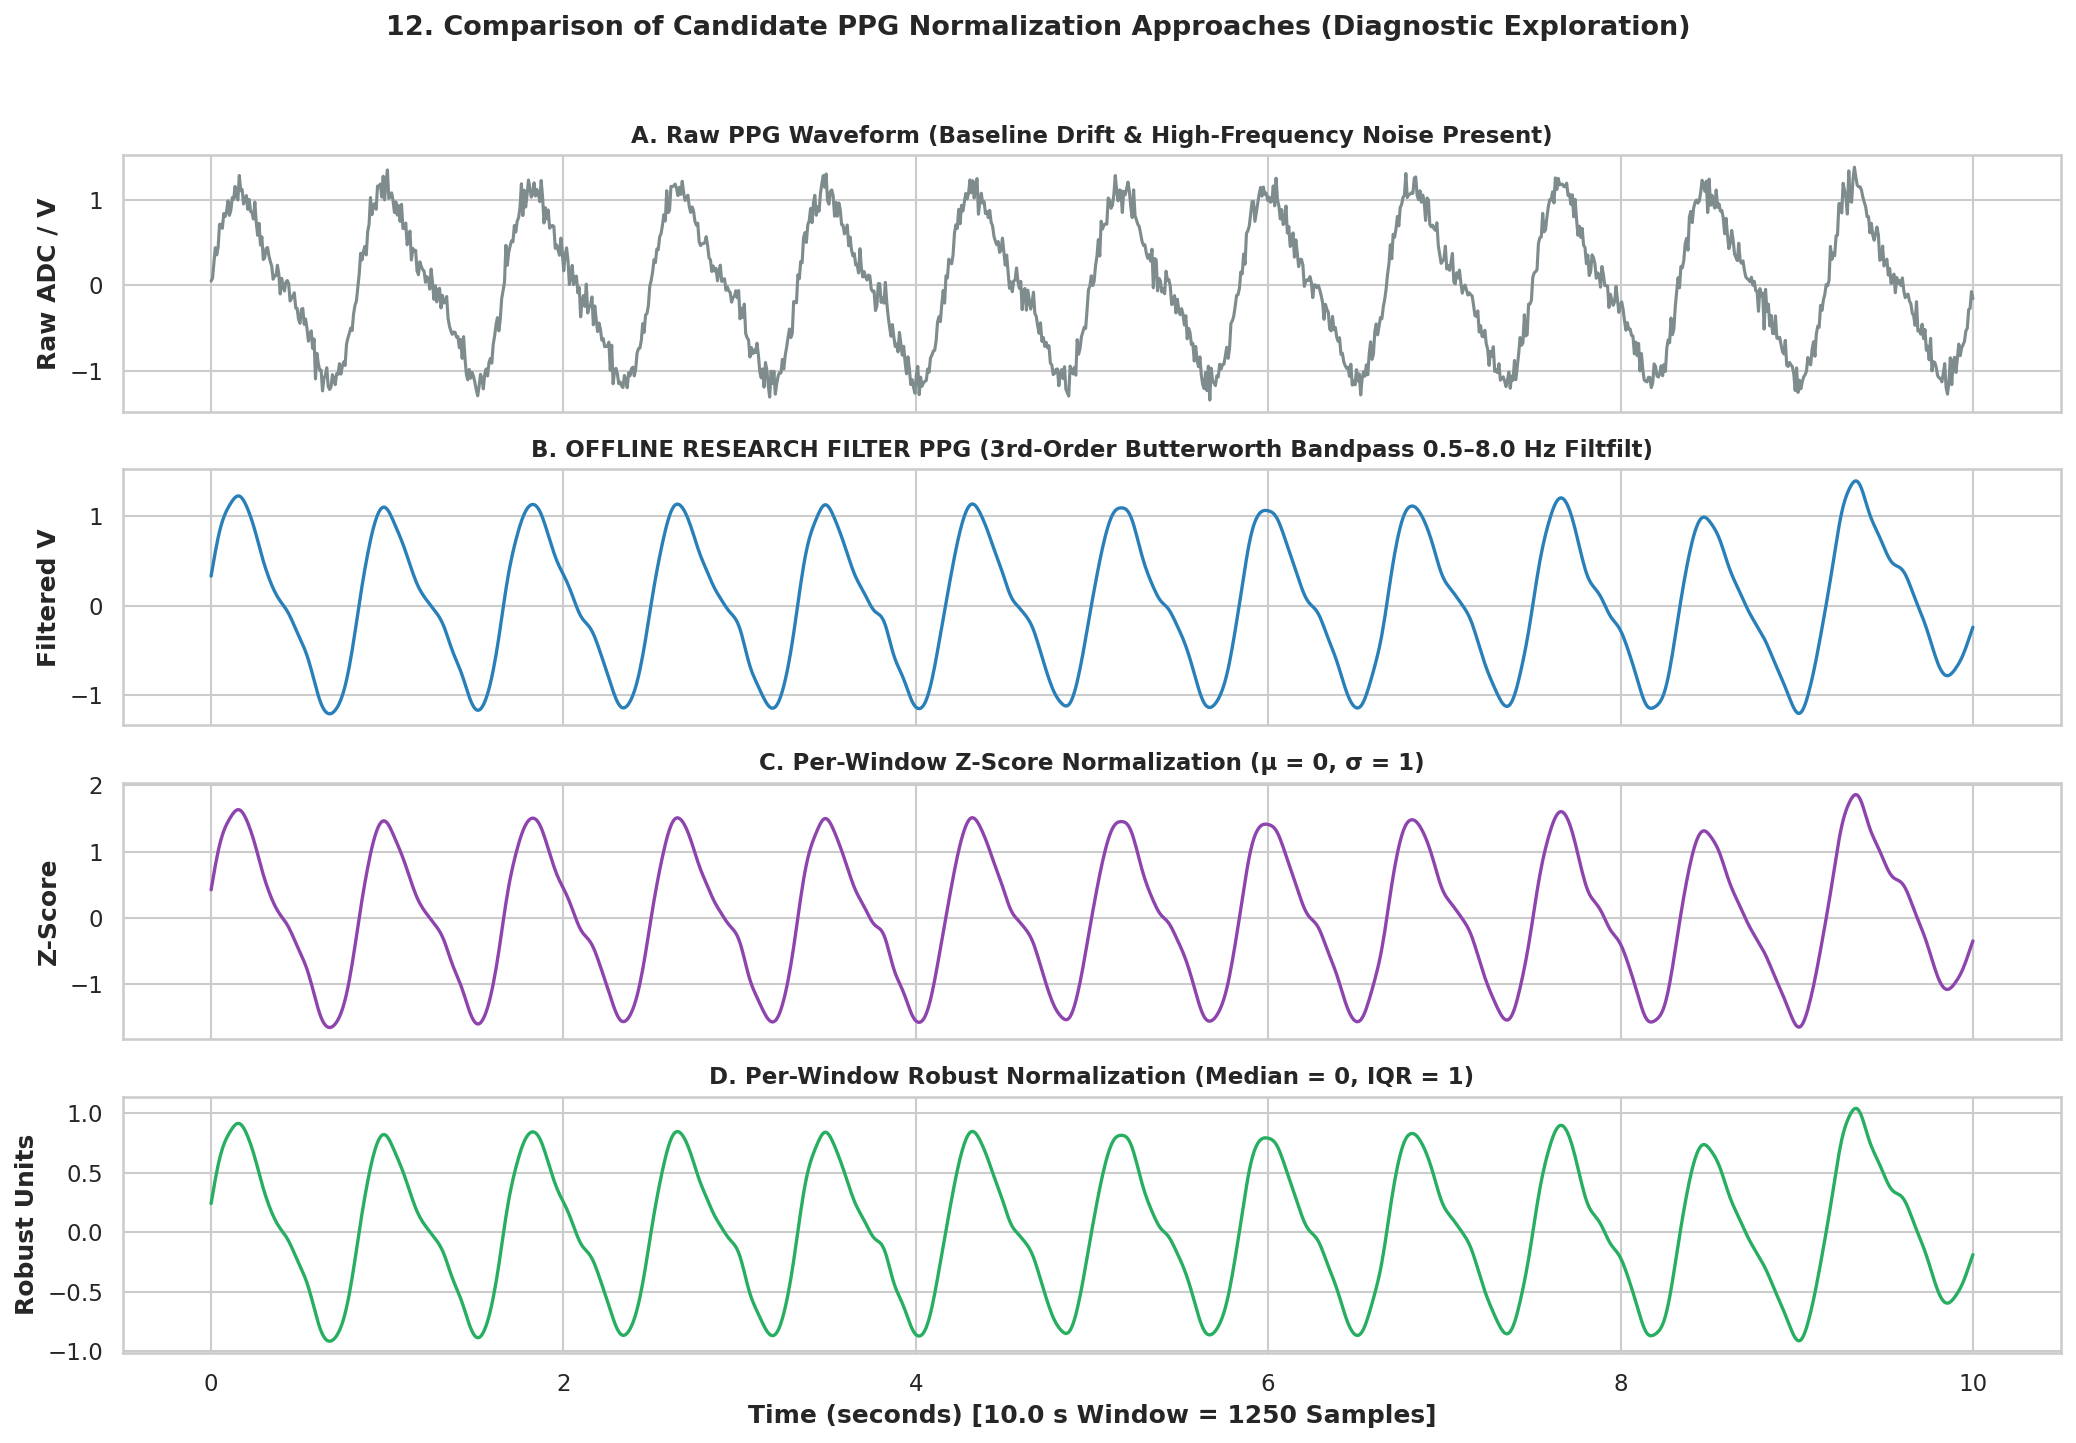

In [12]:
norm_fig = FIGURES_DIR / "12_ppg_normalization_comparison.png"
if norm_fig.exists():
    display(Image(filename=str(norm_fig), width=900))
else:
    print("Normalization comparison figure will appear after pipeline execution.")

## 15. Final Dataset Summary & Phase 2 Conclusion

### Summary of Accomplishments:
1. **Window Generation**: Converted 12,000 continuous records into 10-second non-overlapping modeling windows ($W = 1250$ samples).
2. **Decoupled Quality Gates**: Evaluated PPG signal integrity independently from ABP reference validity.
3. **Beat-Wise Target Derivation**: Extracted physiological SBP, DBP, and MAP from detected systolic peaks and diastolic valleys.
4. **Zero-Leakage Partitioning**: 70/15/15 train/validation/test partition strictly by `record_id` with 0 record overlap.
5. **No Models Trained**: Pure data engineering and validation pipeline completed.

**Readiness for Phase 3 Modeling**: **YES**

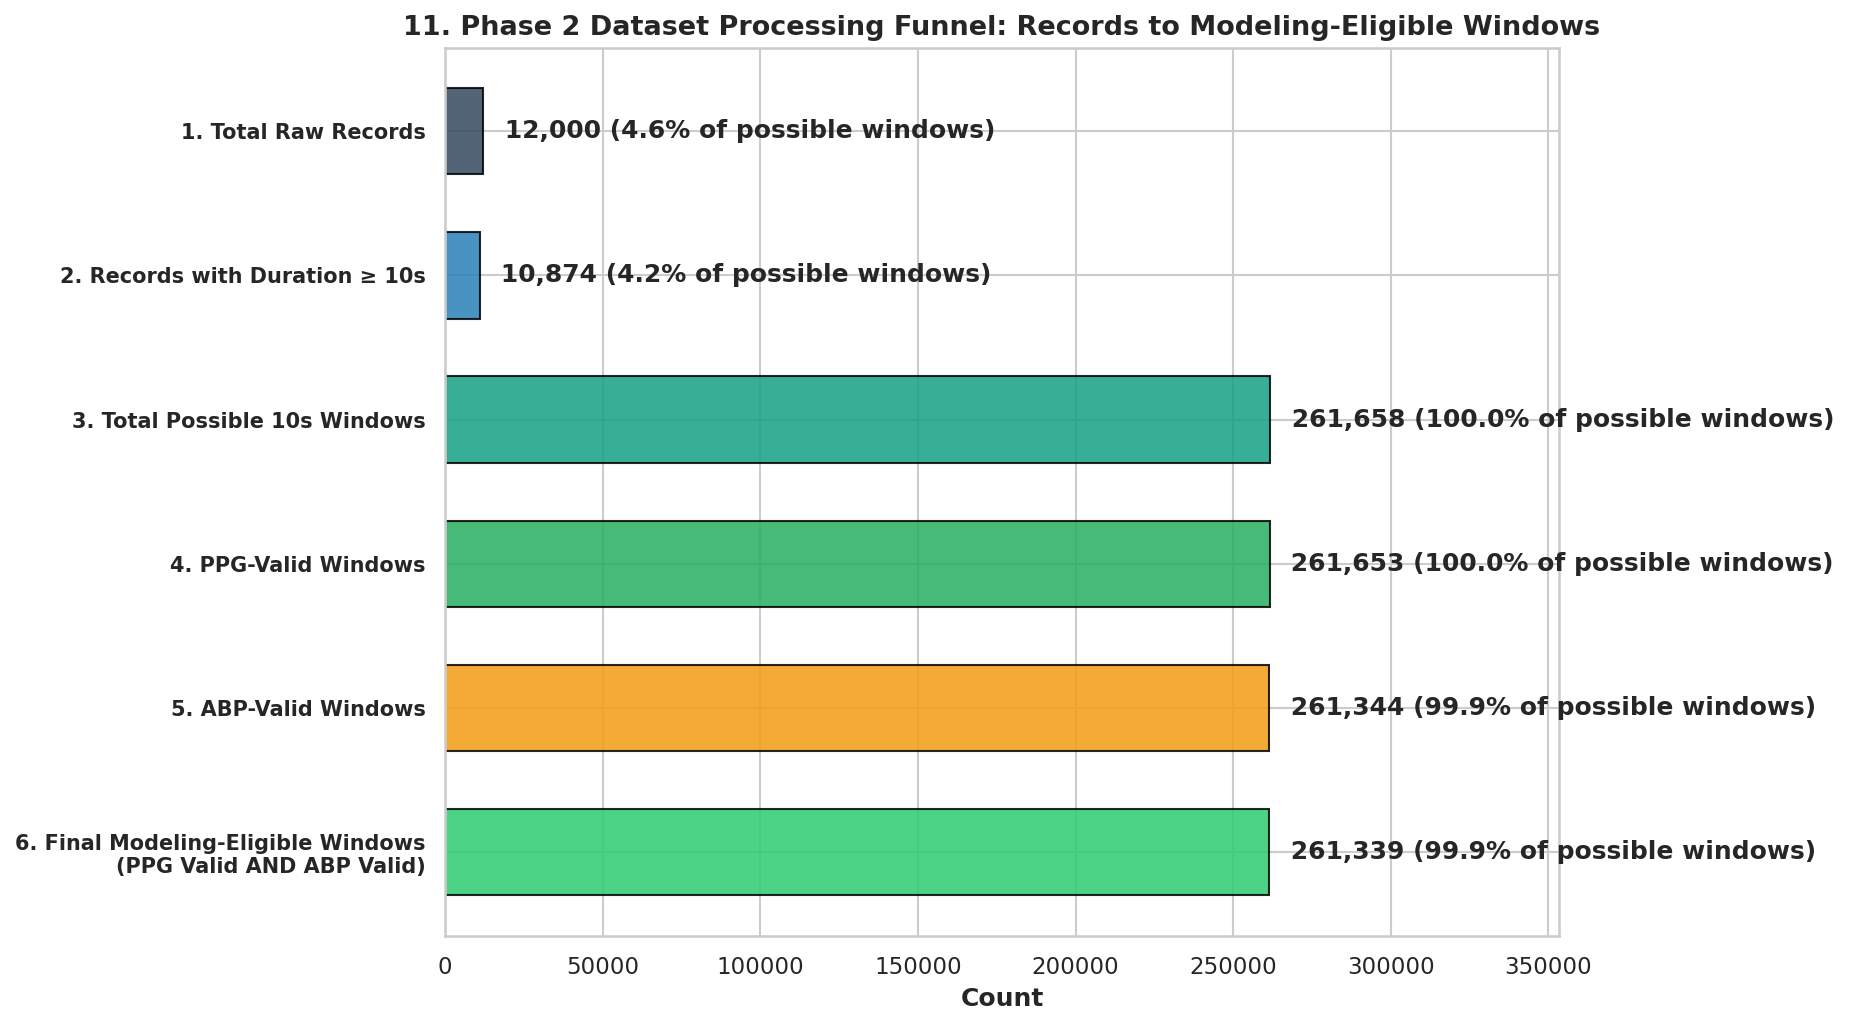

Phase 2 Notebook Execution Complete. Pipeline is fully validated and ready for Phase 3.


In [13]:
funnel_fig = FIGURES_DIR / "11_dataset_processing_funnel.png"
if funnel_fig.exists():
    display(Image(filename=str(funnel_fig), width=900))

print("Phase 2 Notebook Execution Complete. Pipeline is fully validated and ready for Phase 3.")